ECS 427/627: Multi-agent Reinforcement Learning - Assignment 1
Question 1: Differential-Drive Robot with Orientation-Dependent Planning

(a) MDP FORMULATION
Grid Size: 10x10
Obstacles: [(0, 9), (4, 1), (4, 2), (6, 5), (9, 1)]
Goal: (5, 0)
Number of states: 400 + terminal
Number of actions: 3

    MDP Formulation:
    States: S = {(x, y, θ) | x ∈ [0,9], y ∈ [0,9], θ ∈ {0, π/2, π, 3π/2}} ∪ {TERMINAL}
    Total non-terminal states: 400
    
    Actions: A = {Forward, TurnLeft, TurnRight}
    
    Transition Model:
    - Forward: 
        P(forward | s, Forward) = 0.8
        P(slip_left | s, Forward) = 0.1
        P(slip_right | s, Forward) = 0.1
    - TurnLeft: Deterministic, θ' = (θ + π/2) mod 2π
    - TurnRight: Deterministic, θ' = (θ - π/2) mod 2π
    - Collision → TERMINAL state
    
    Reward Structure:
    - Step cost: -1
    - Collision: -100 (terminal)
    - Goal reached: 50 (terminal)
    
    Discount Factor: γ = 0.99
    
    Obstacles: [(0, 9), (4, 1), (4, 2), (6, 5), (9, 1)

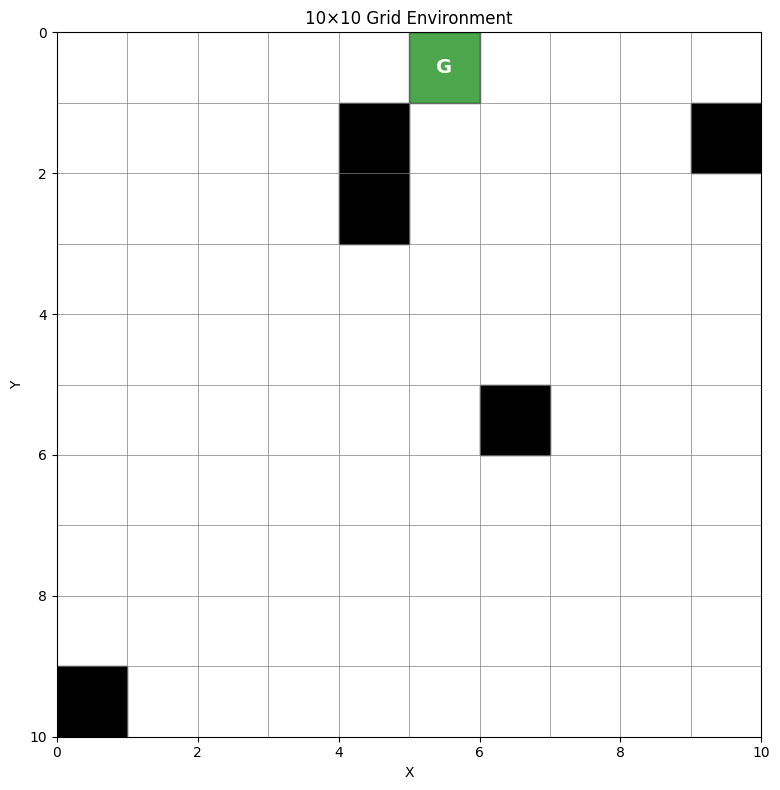

Saved: grid_environment.png

HAND CALCULATION EXAMPLE

Goal: (5, 0)
Example state for hand calculation: (6, 0, θ=0 [East])
Step reward: -1, Collision reward: -100, Goal reward: 50
Discount factor γ = 0.99

--- Initialization ---
V₀(s) = 0 for all states

--- Iteration 1 ---
For state (6, 0, 0):

  Action: Forward
    P=0.8: next=(7, 0, 0), R=-1 + γ×V₀((7, 0, 0))=0.99×0 → contribution = 0.8×(-1+0) = -0.80
    P=0.1: next=TERMINAL, R=-101, terminal → contribution = 0.1×-101 = -10.10
    P=0.1: next=(6, 1, 0), R=-1 + γ×V₀((6, 1, 0))=0.99×0 → contribution = 0.1×(-1+0) = -0.10
  Q(s, Forward) = -11.0000

  Action: TurnLeft
    P=1.0: next=(6, 0, 1), R=-1 + γ×V₀((6, 0, 1))=0.99×0 → contribution = 1.0×(-1+0) = -1.00
  Q(s, TurnLeft) = -1.0000

  Action: TurnRight
    P=1.0: next=(6, 0, 3), R=-1 + γ×V₀((6, 0, 3))=0.99×0 → contribution = 1.0×(-1+0) = -1.00
  Q(s, TurnRight) = -1.0000

  V_1(6, 0, 0) = -1.0000

  V_2(6, 0, 0) = 2.9600

  V_3(6, 0, 0) = 26.4329

(b) VALUE ITERATION

=== VALUE ITE

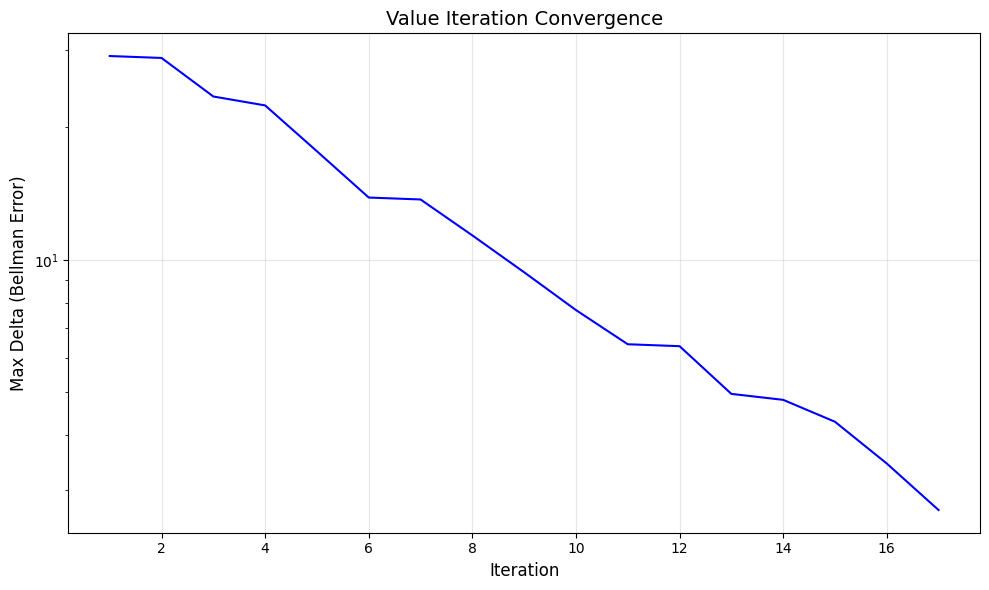

Saved: convergence_vi.png


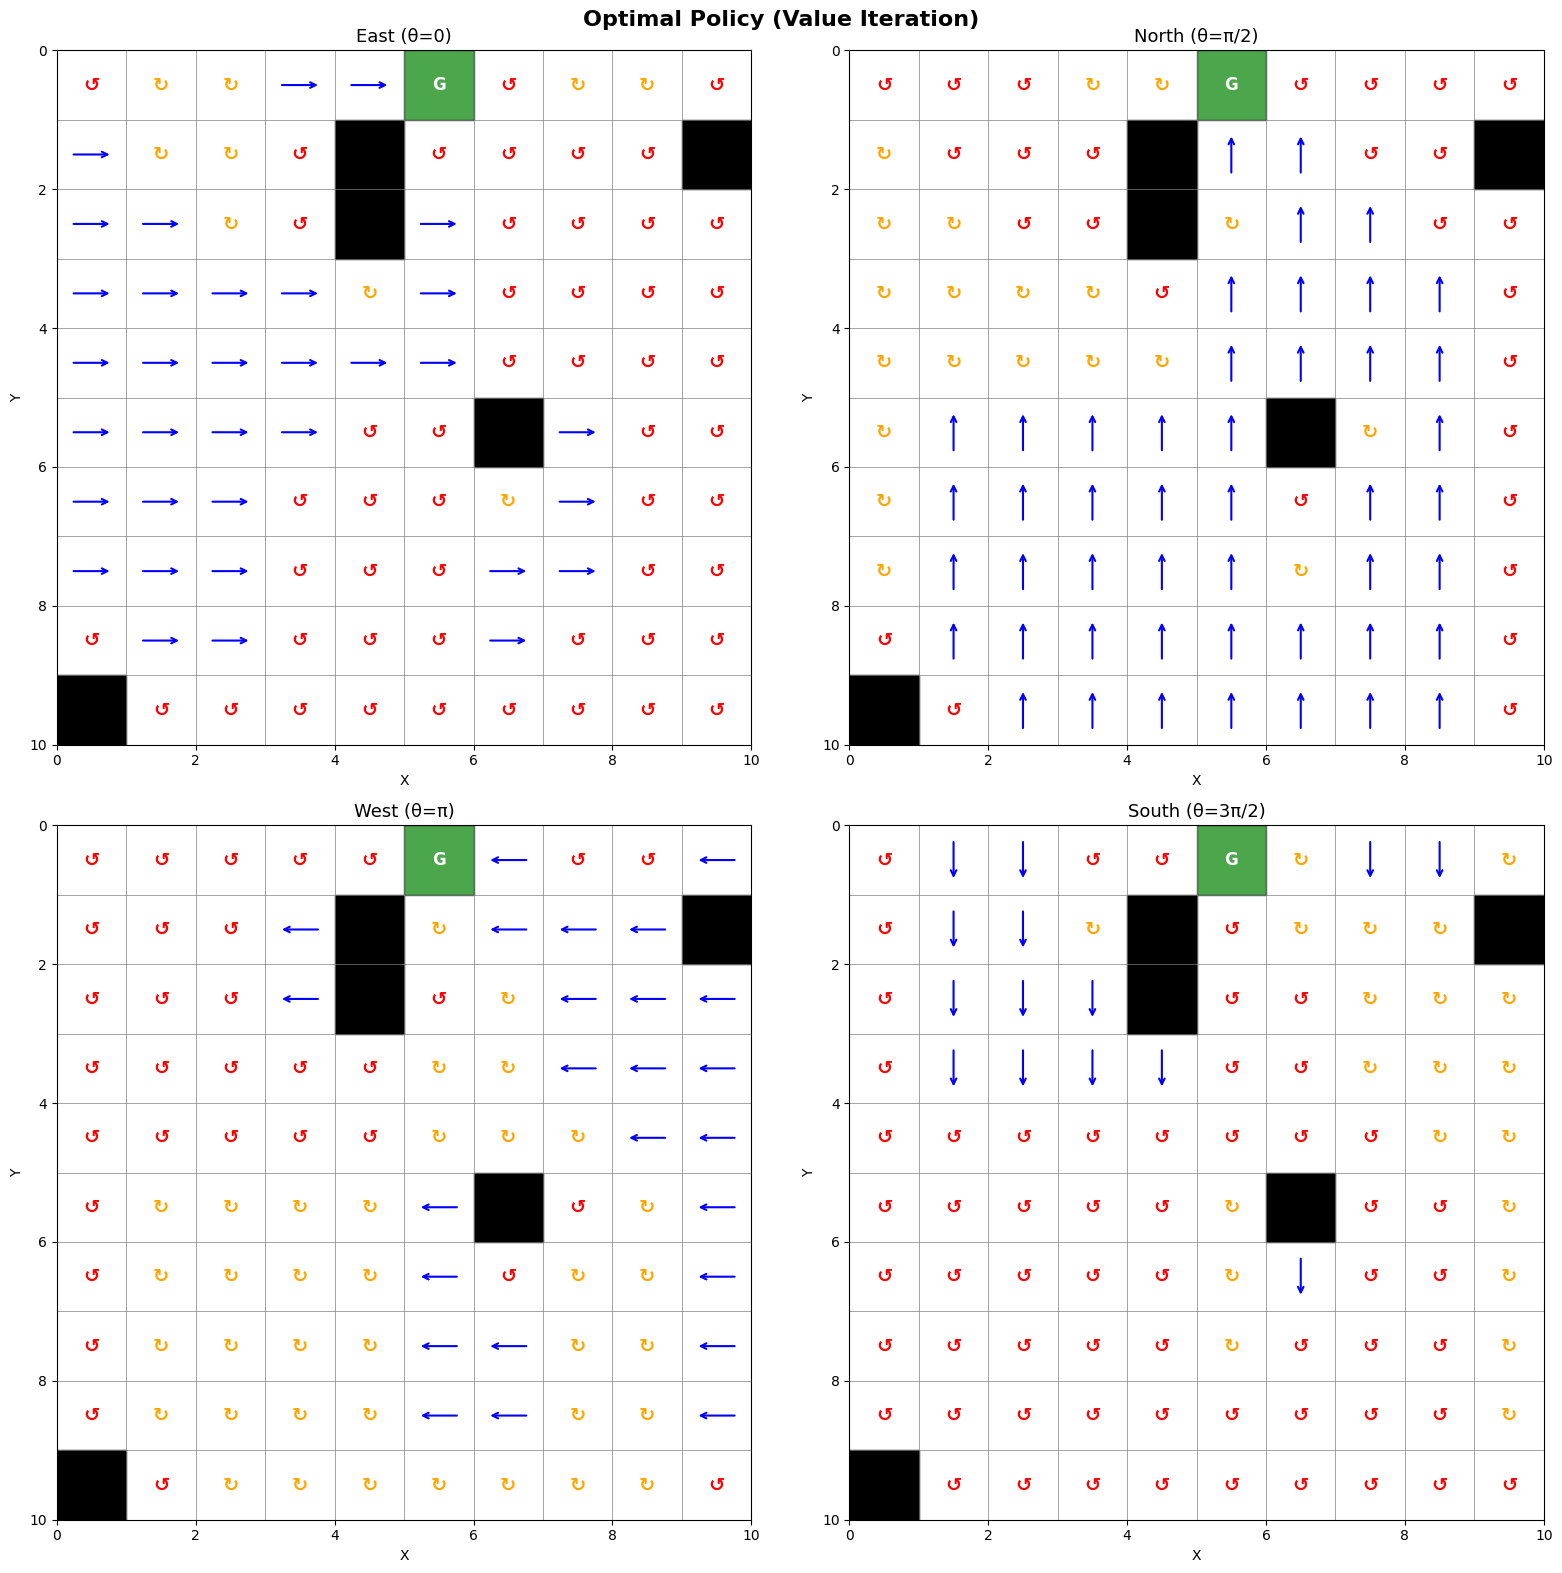

Saved: policy_vi.png


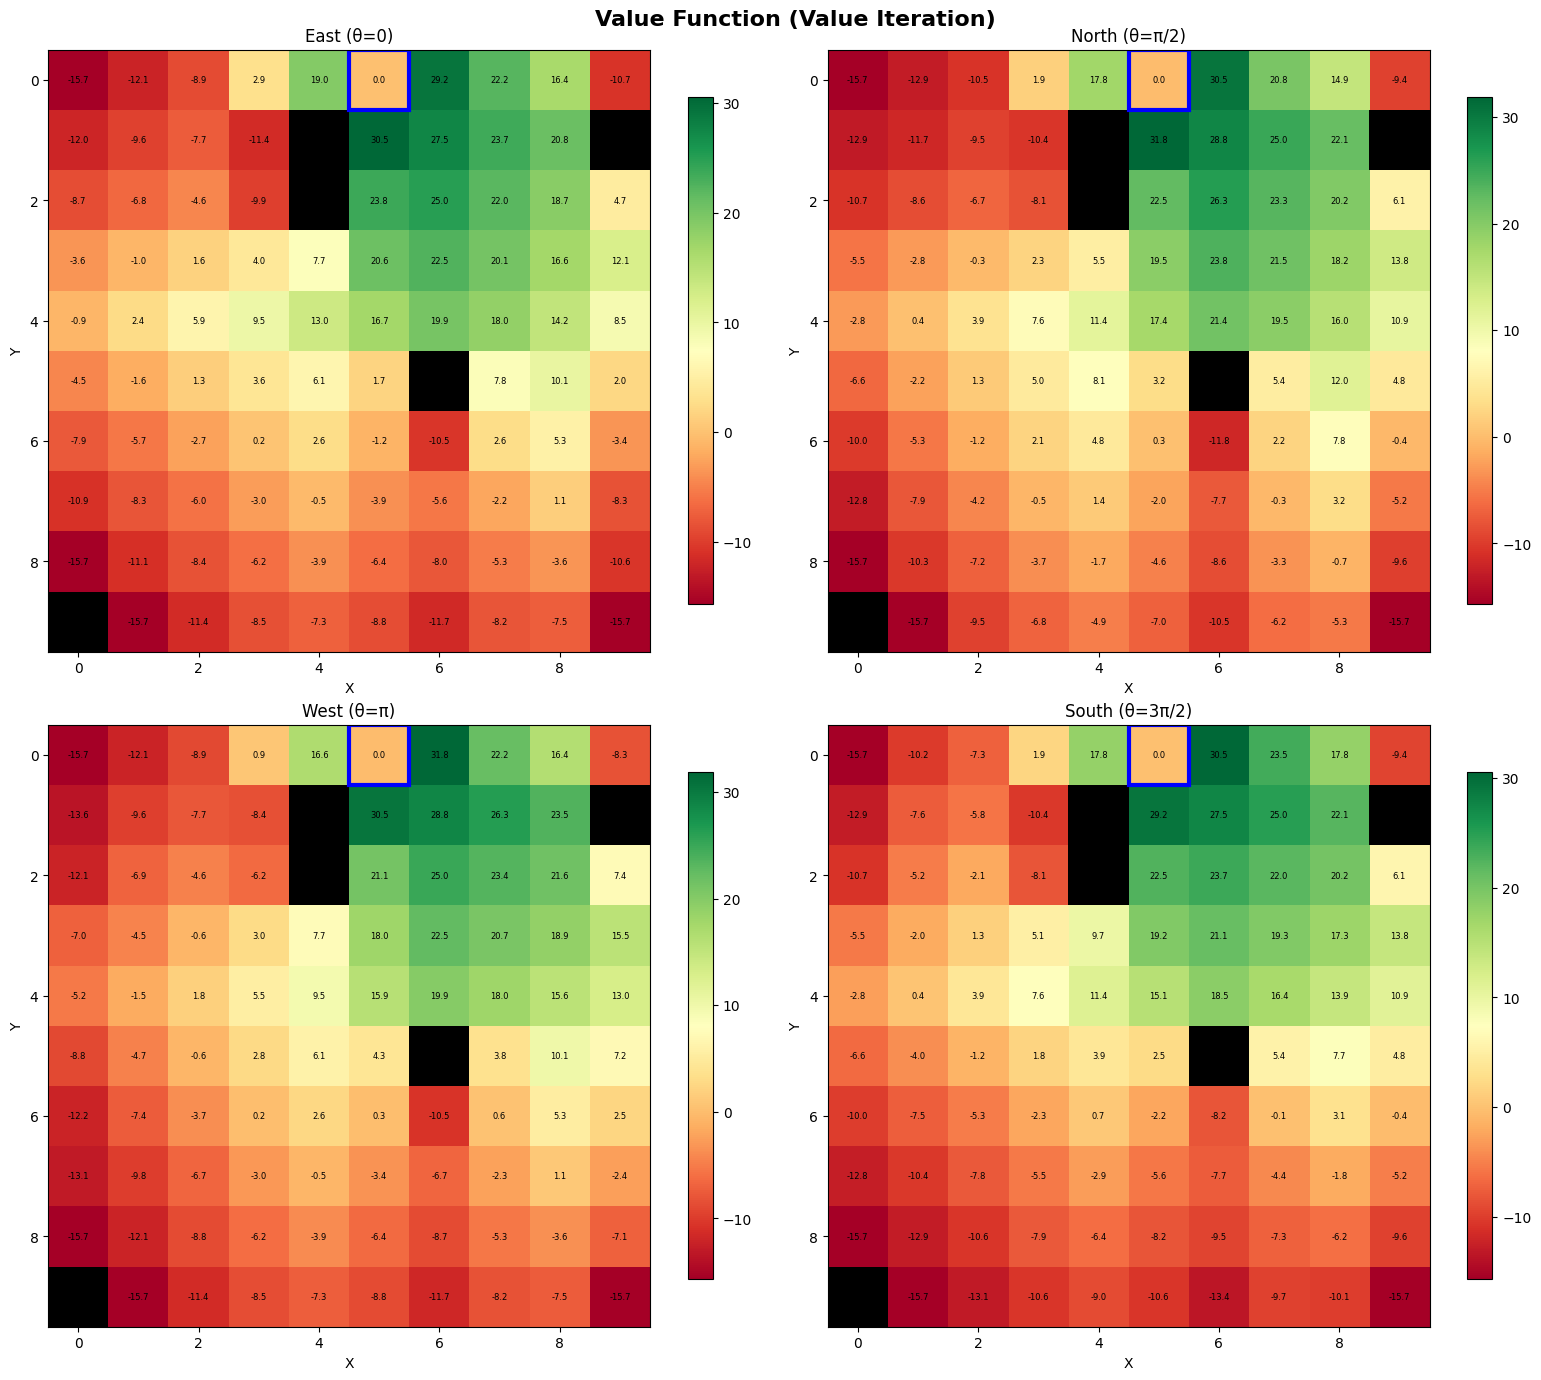

Saved: value_function_vi.png

(c) POLICY ITERATION

=== POLICY ITERATION ===
Converged in 11 iterations
Runtime: 0.6668 seconds
Peak memory: 209.92 KB

FIRST 3 ITERATIONS OF POLICY ITERATION (for hand-calculation comparison)
Showing for orientation θ=0 (East) only for brevity


--- Iteration 1 ---

V after iteration 1 (θ=0):
--------------------------------------------------------------------------------
y\x |   0   |   1   |   2   |   3   |   4   |   5   |   6   |   7   |   8   |   9  
--------------------------------------------------------------------------------
 0  | -29.60| -22.22| -30.71| -30.12| -15.71|  GOAL | -37.29| -30.63| -22.22| -93.11| 
 1  | -24.27| -24.64| -29.10| -81.53|  OBS  | -22.53| -33.06| -34.43| -31.38|  OBS  | 
 2  | -22.22| -72.13| -84.49| -91.84|  OBS  | -15.71| -22.92| -22.54| -21.91| -22.22| 
 3  | -21.67| -22.22| -81.56| -29.51| -22.22| -38.89| -22.22| -22.22| -23.48| -92.31| 
 4  | -23.00| -76.45| -35.72| -33.02| -34.71| -37.48| -22.22| -21.59| -79.38| -

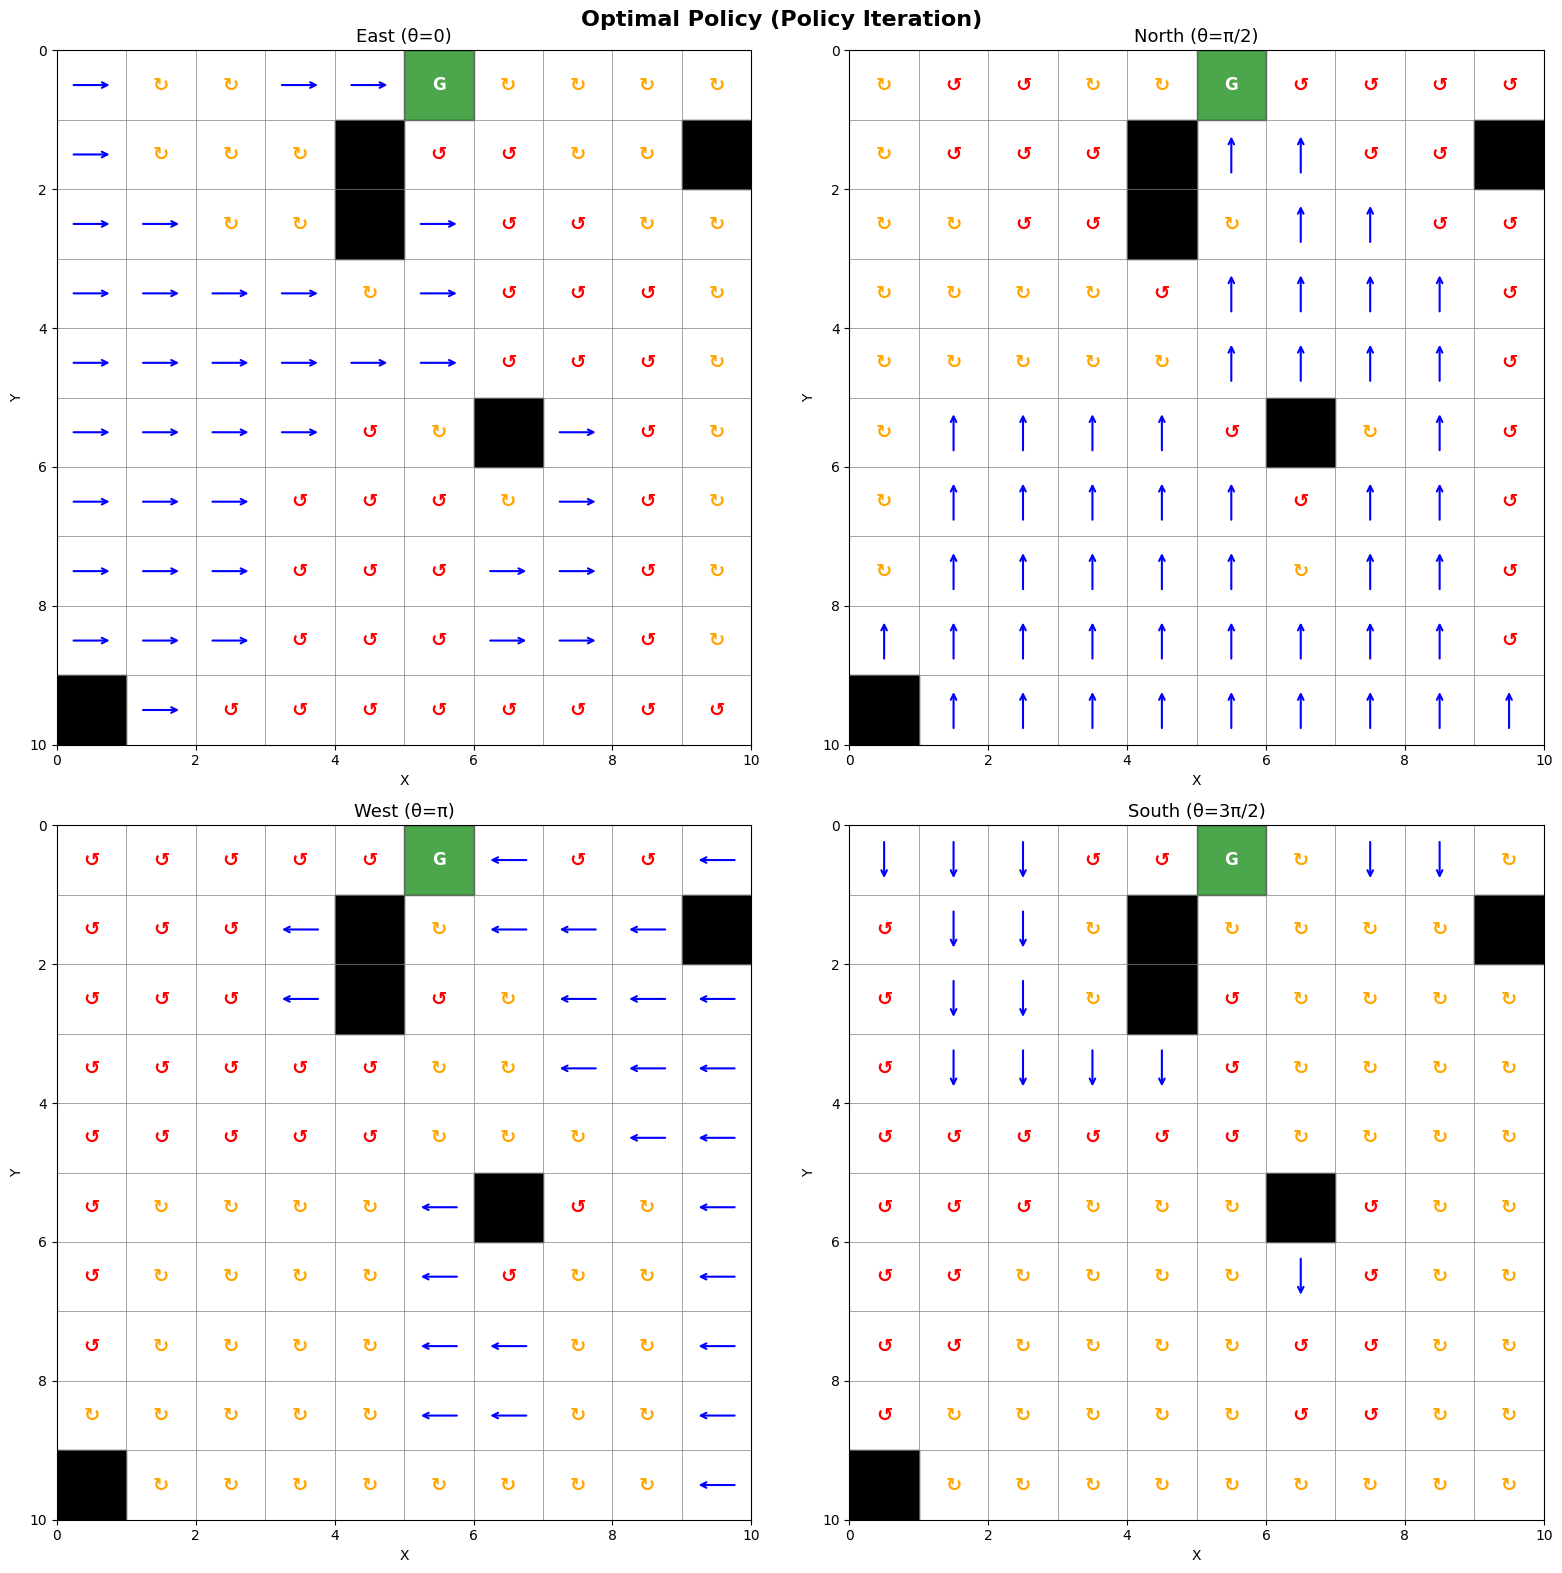

Saved: policy_pi.png


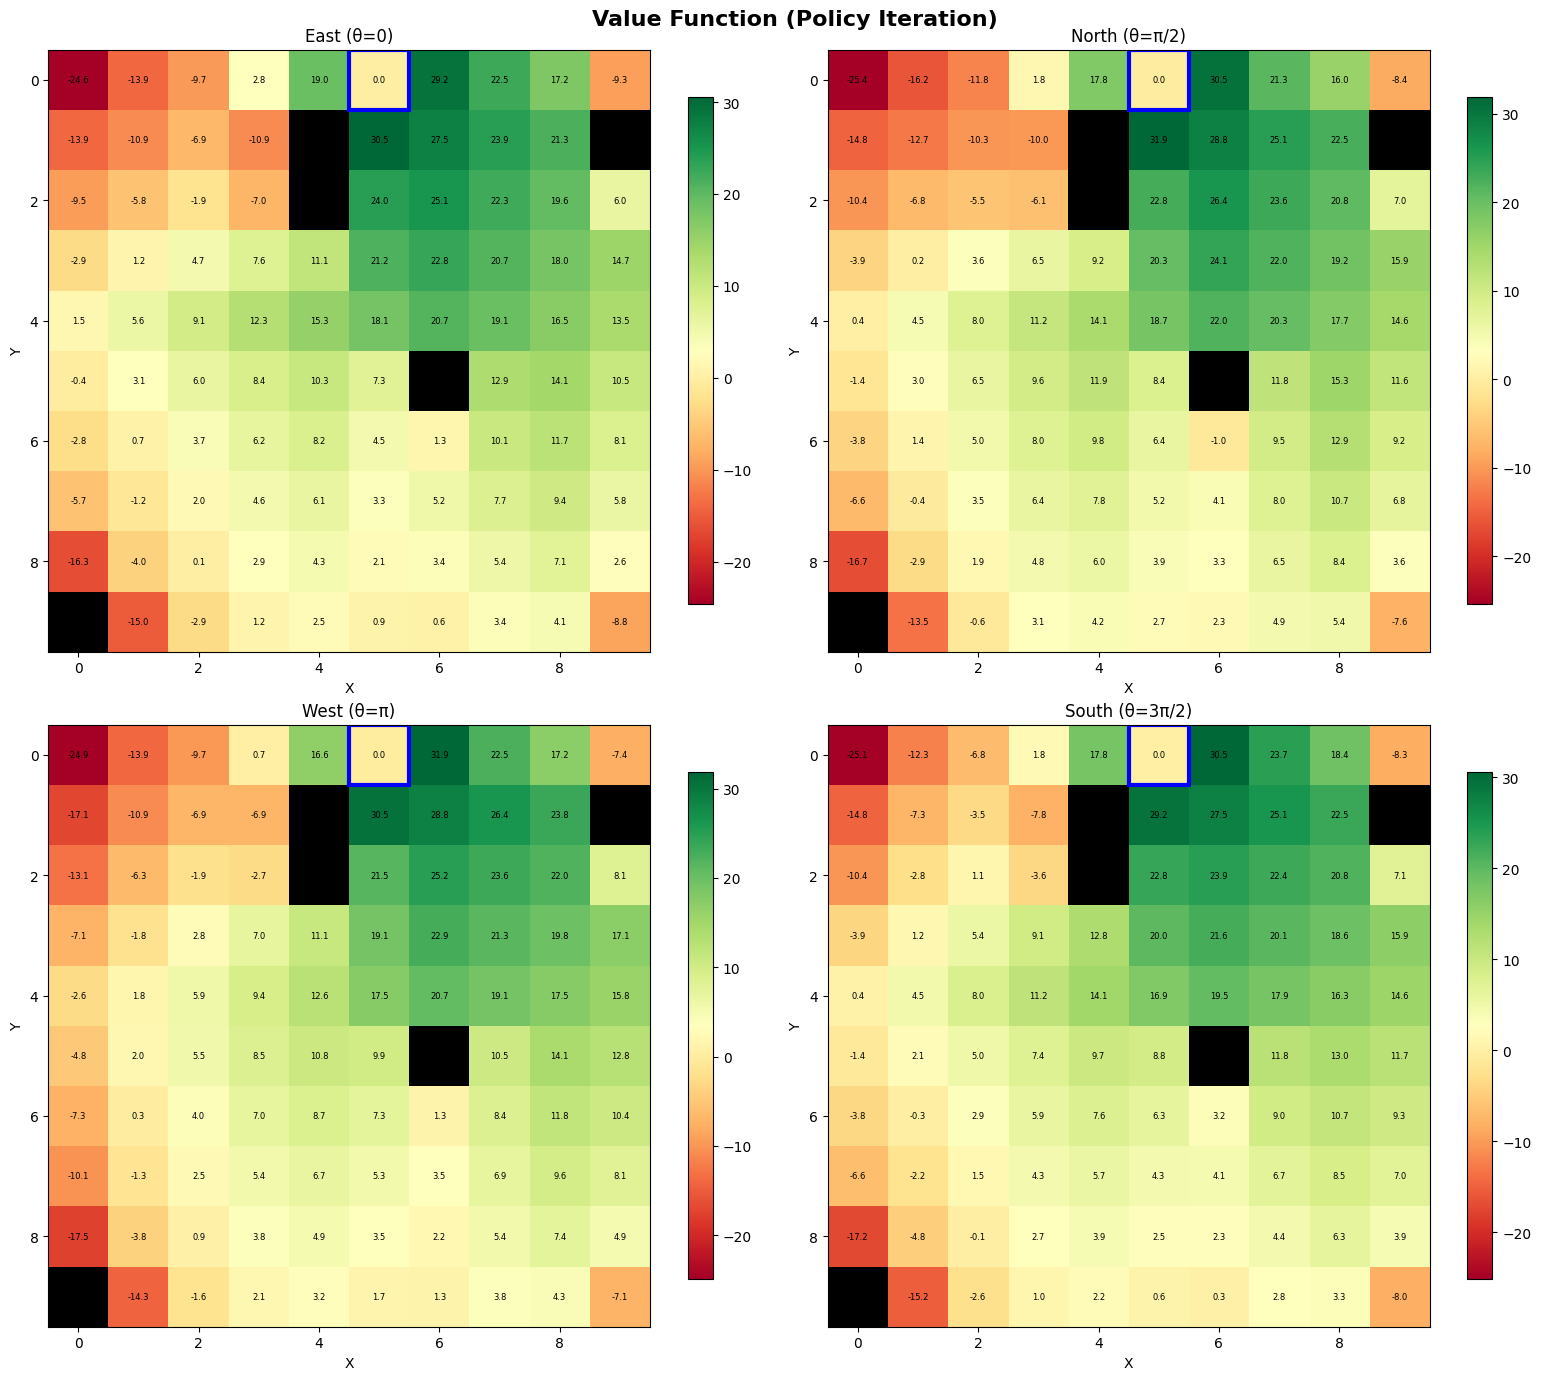

Saved: value_function_pi.png

(d) COMPARISON: VALUE ITERATION vs POLICY ITERATION

    ┌─────────────────────┬──────────────────┬──────────────────┐
    │ Metric              │ Value Iteration  │ Policy Iteration │
    ├─────────────────────┼──────────────────┼──────────────────┤
    │ Iterations          │               17 │               11 │
    │ Runtime (seconds)   │           0.3601 │           0.6668 │
    │ Peak Memory (KB)    │           141.16 │           209.92 │
    │ Policy Agreement    │ 324/400 states match          │
    └─────────────────────┴──────────────────┴──────────────────┘
    
  Max value difference between VI and PI: 14.094843
  Mean value difference: 4.651889

(e) POLICY VISUALIZATION (Orientation-Aware)
See saved figures: policy_vi.png, policy_pi.png


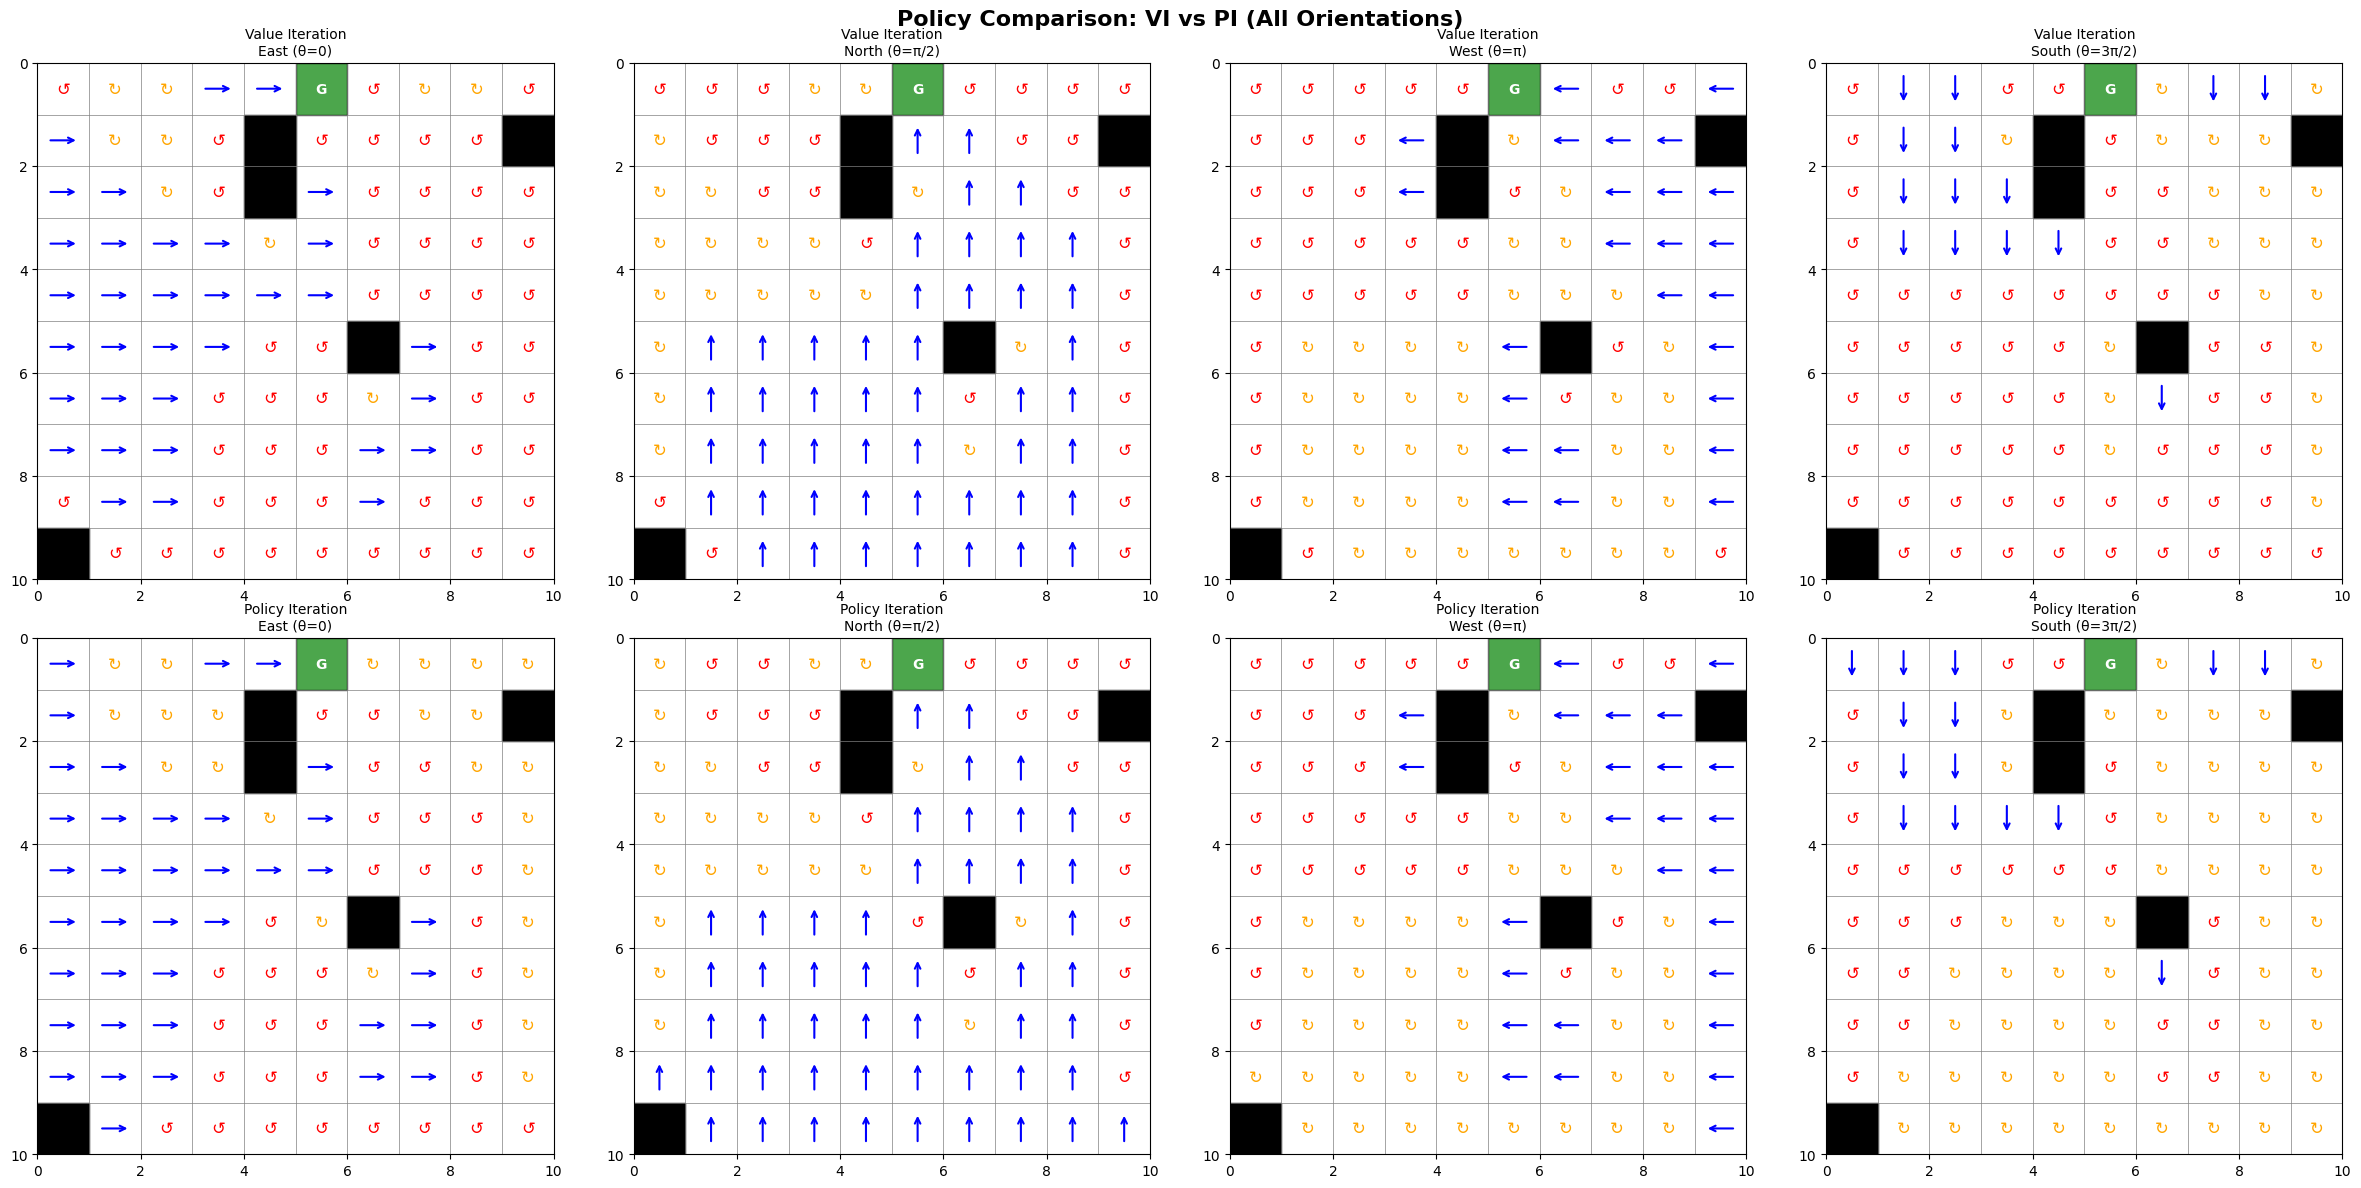

Saved: policy_comparison.png

(f) REWARD STRUCTURE COMPARISON

--- Reward Config: Original ---
    Step: -1, Collision: -100, Goal: 50
Grid Size: 10x10
Obstacles: [(0, 9), (4, 1), (4, 2), (6, 5), (9, 1)]
Goal: (5, 0)
Number of states: 400 + terminal
Number of actions: 3

=== VALUE ITERATION ===
Converged in 17 iterations
Runtime: 0.2841 seconds
Peak memory: 144.38 KB
Final delta: 2.70575233

=== POLICY ITERATION ===
Converged in 14 iterations
Runtime: 0.7540 seconds
Peak memory: 207.47 KB


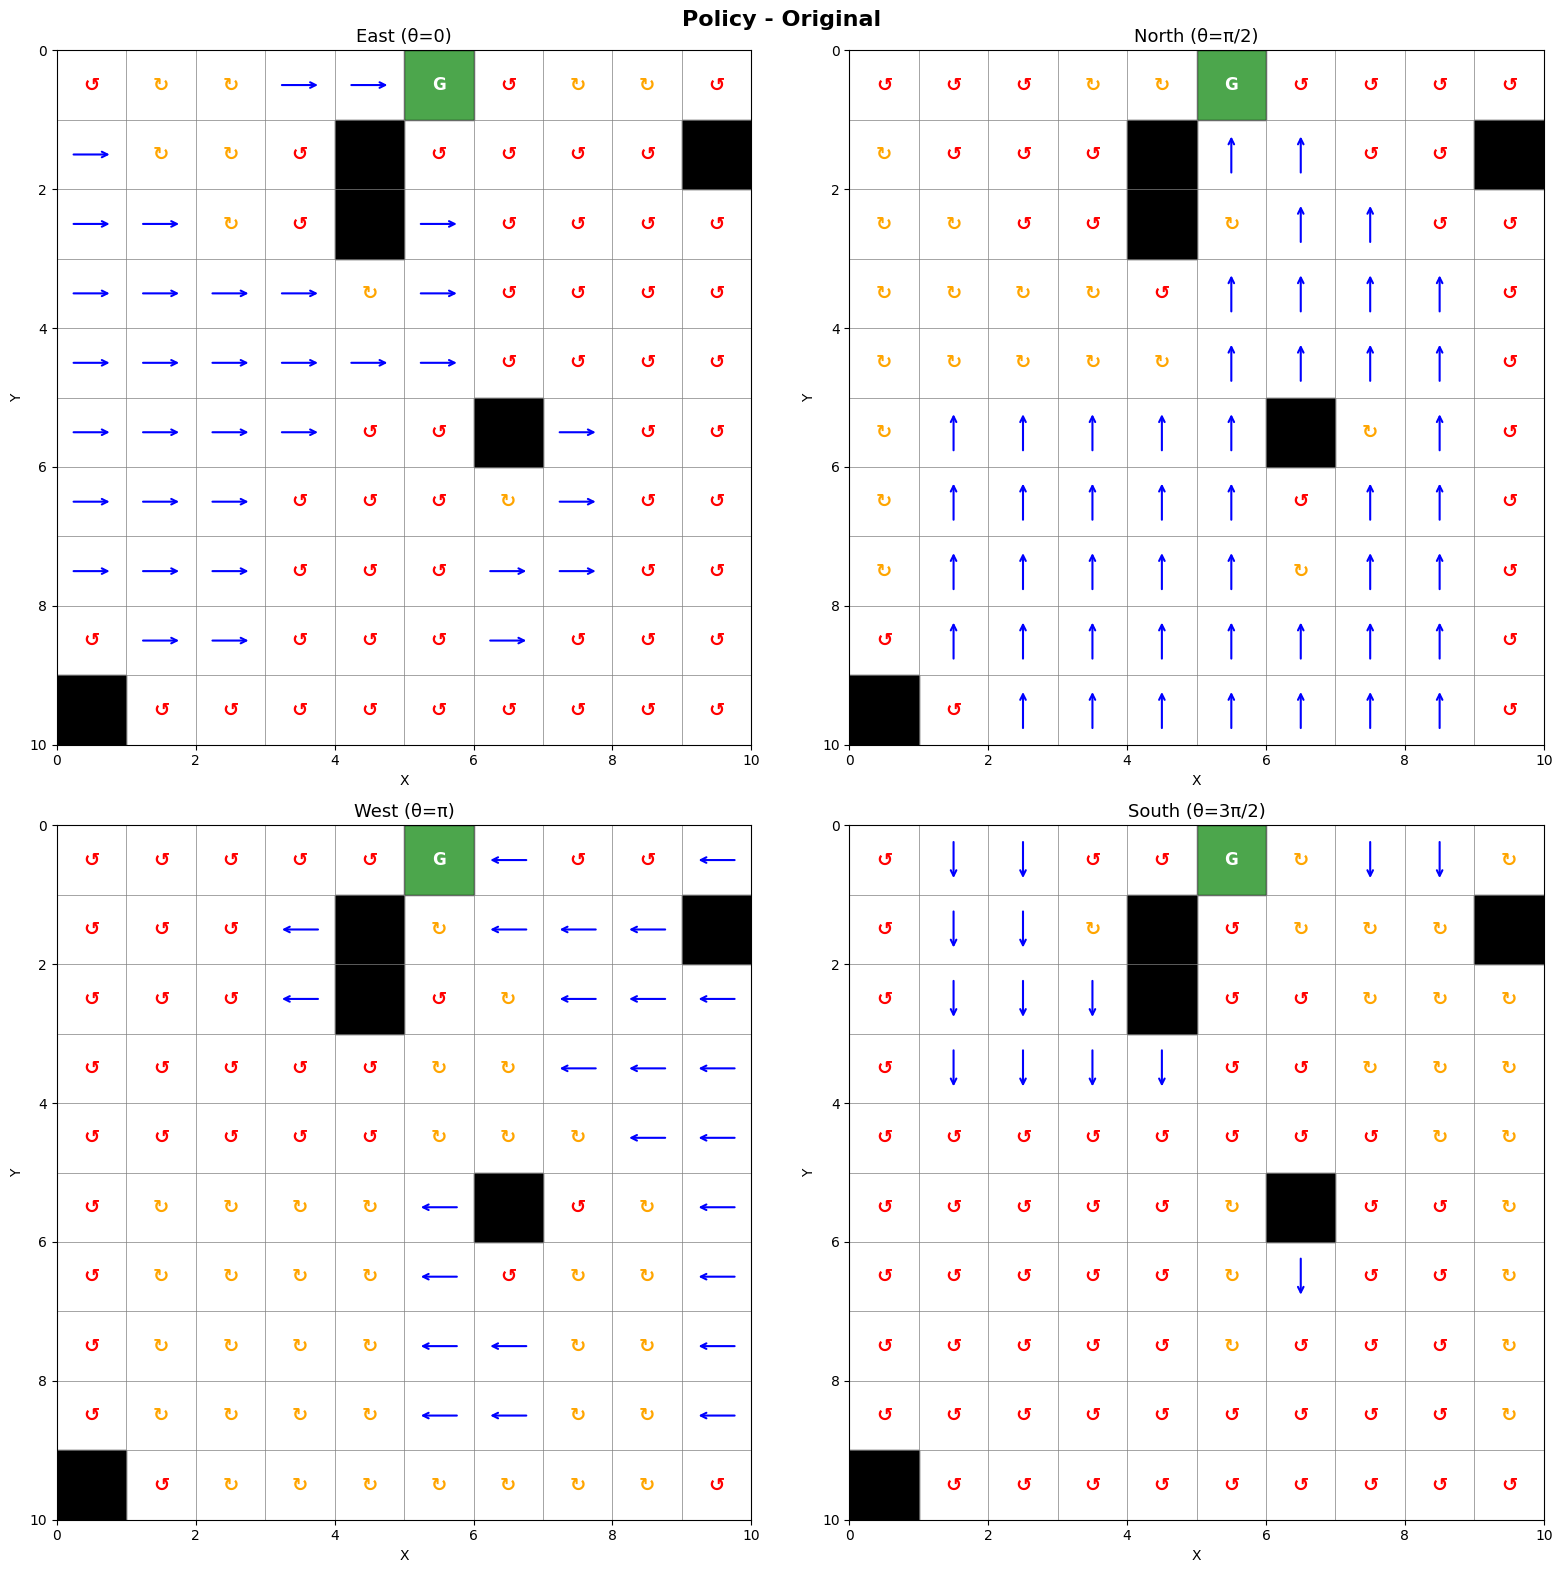

Saved: policy_original.png

--- Reward Config: Config A (High penalty) ---
    Step: -2, Collision: -200, Goal: 100
Grid Size: 10x10
Obstacles: [(0, 9), (4, 1), (4, 2), (6, 5), (9, 1)]
Goal: (5, 0)
Number of states: 400 + terminal
Number of actions: 3

=== VALUE ITERATION ===
Converged in 24 iterations
Runtime: 0.3192 seconds
Peak memory: 145.47 KB
Final delta: 2.62273403

=== POLICY ITERATION ===
Converged in 11 iterations
Runtime: 0.9935 seconds
Peak memory: 207.41 KB


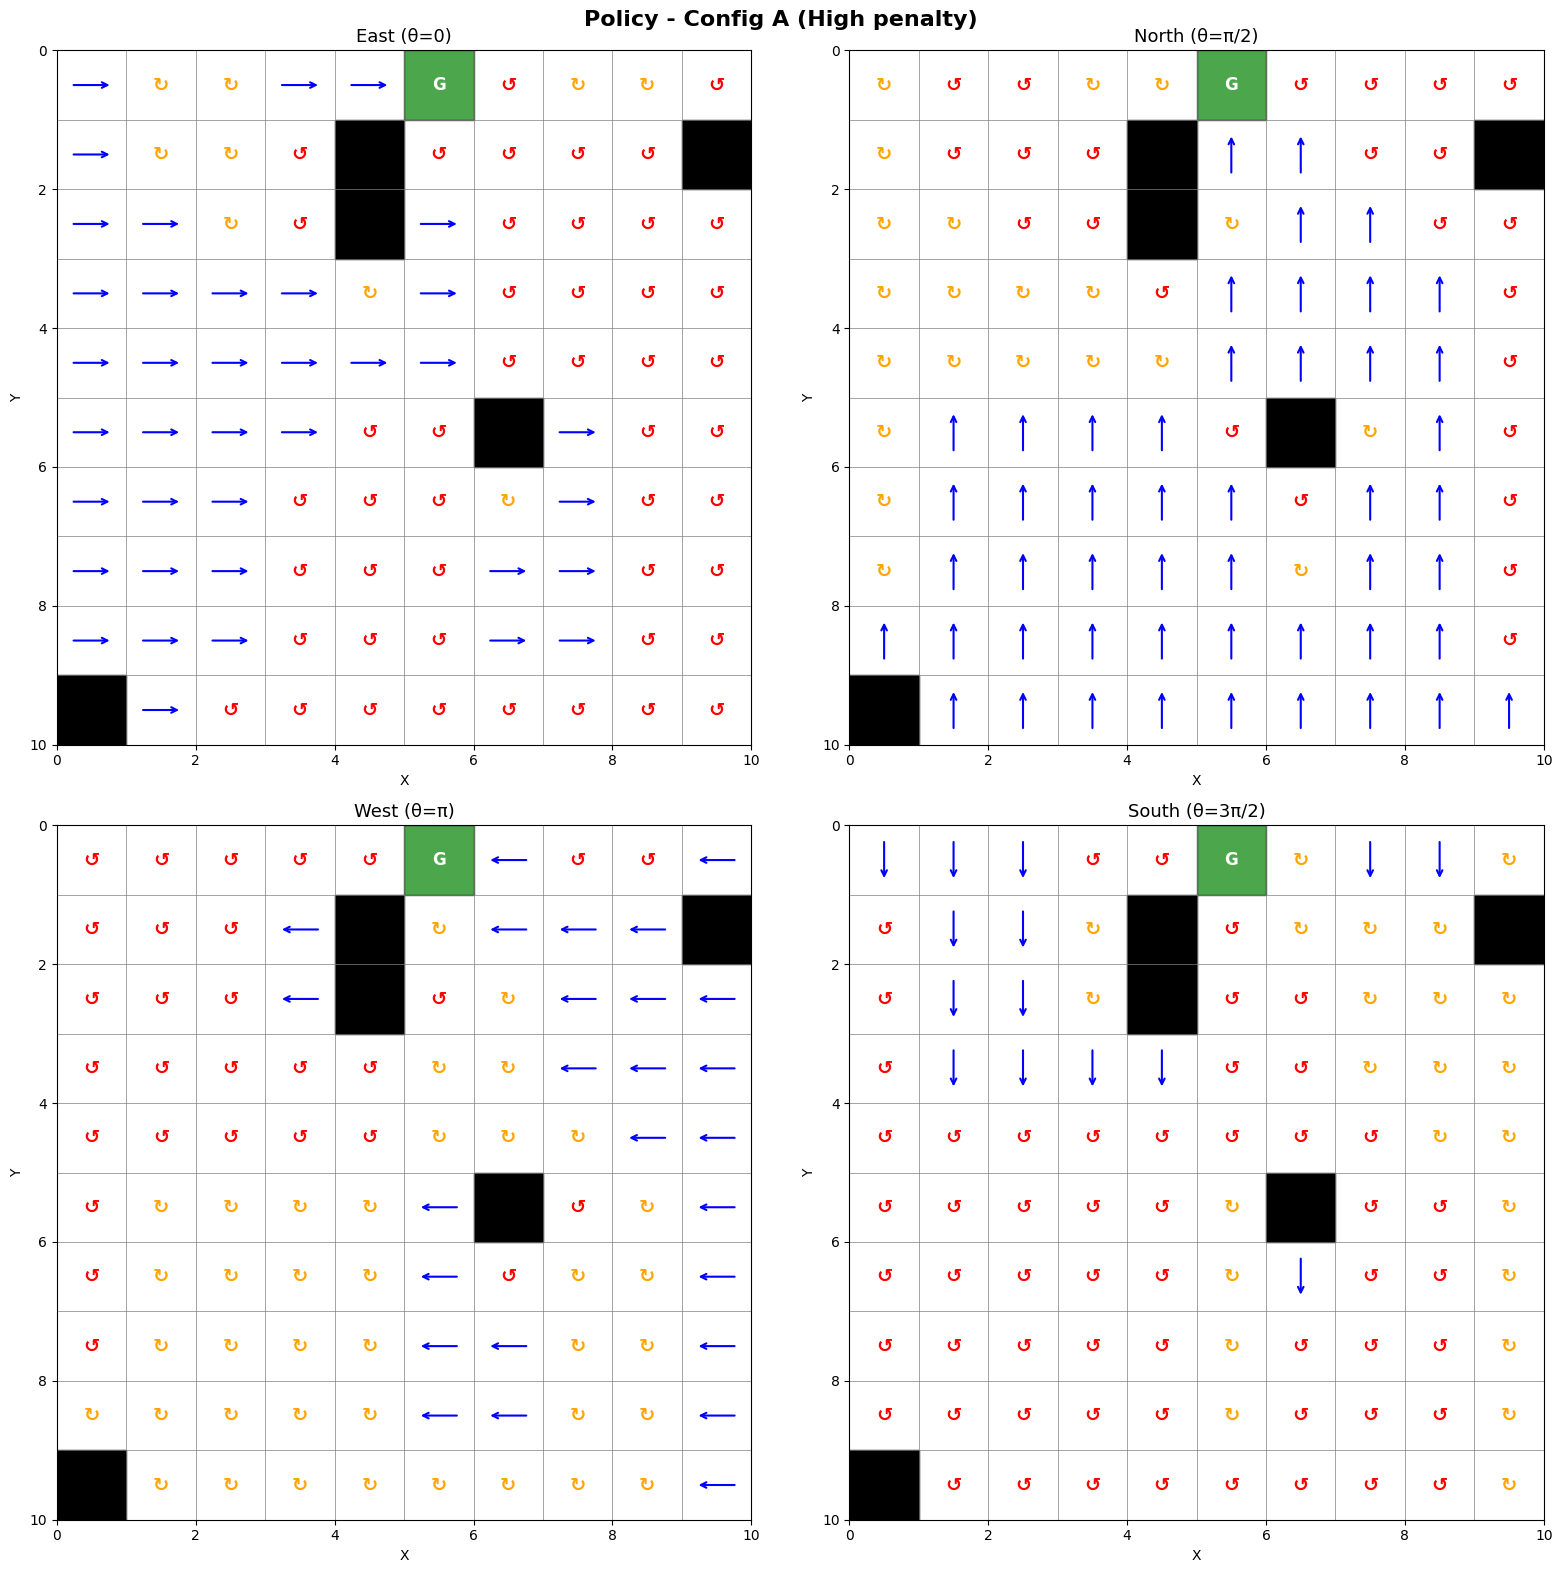

Saved: policy_config_a_(high_penalty).png

--- Reward Config: Config B (Low penalty) ---
    Step: -0.1, Collision: -50, Goal: 200
Grid Size: 10x10
Obstacles: [(0, 9), (4, 1), (4, 2), (6, 5), (9, 1)]
Goal: (5, 0)
Number of states: 400 + terminal
Number of actions: 3

=== VALUE ITERATION ===
Converged in 29 iterations
Runtime: 0.5604 seconds
Peak memory: 144.49 KB
Final delta: 2.84473151

=== POLICY ITERATION ===
Converged in 12 iterations
Runtime: 1.1303 seconds
Peak memory: 207.36 KB


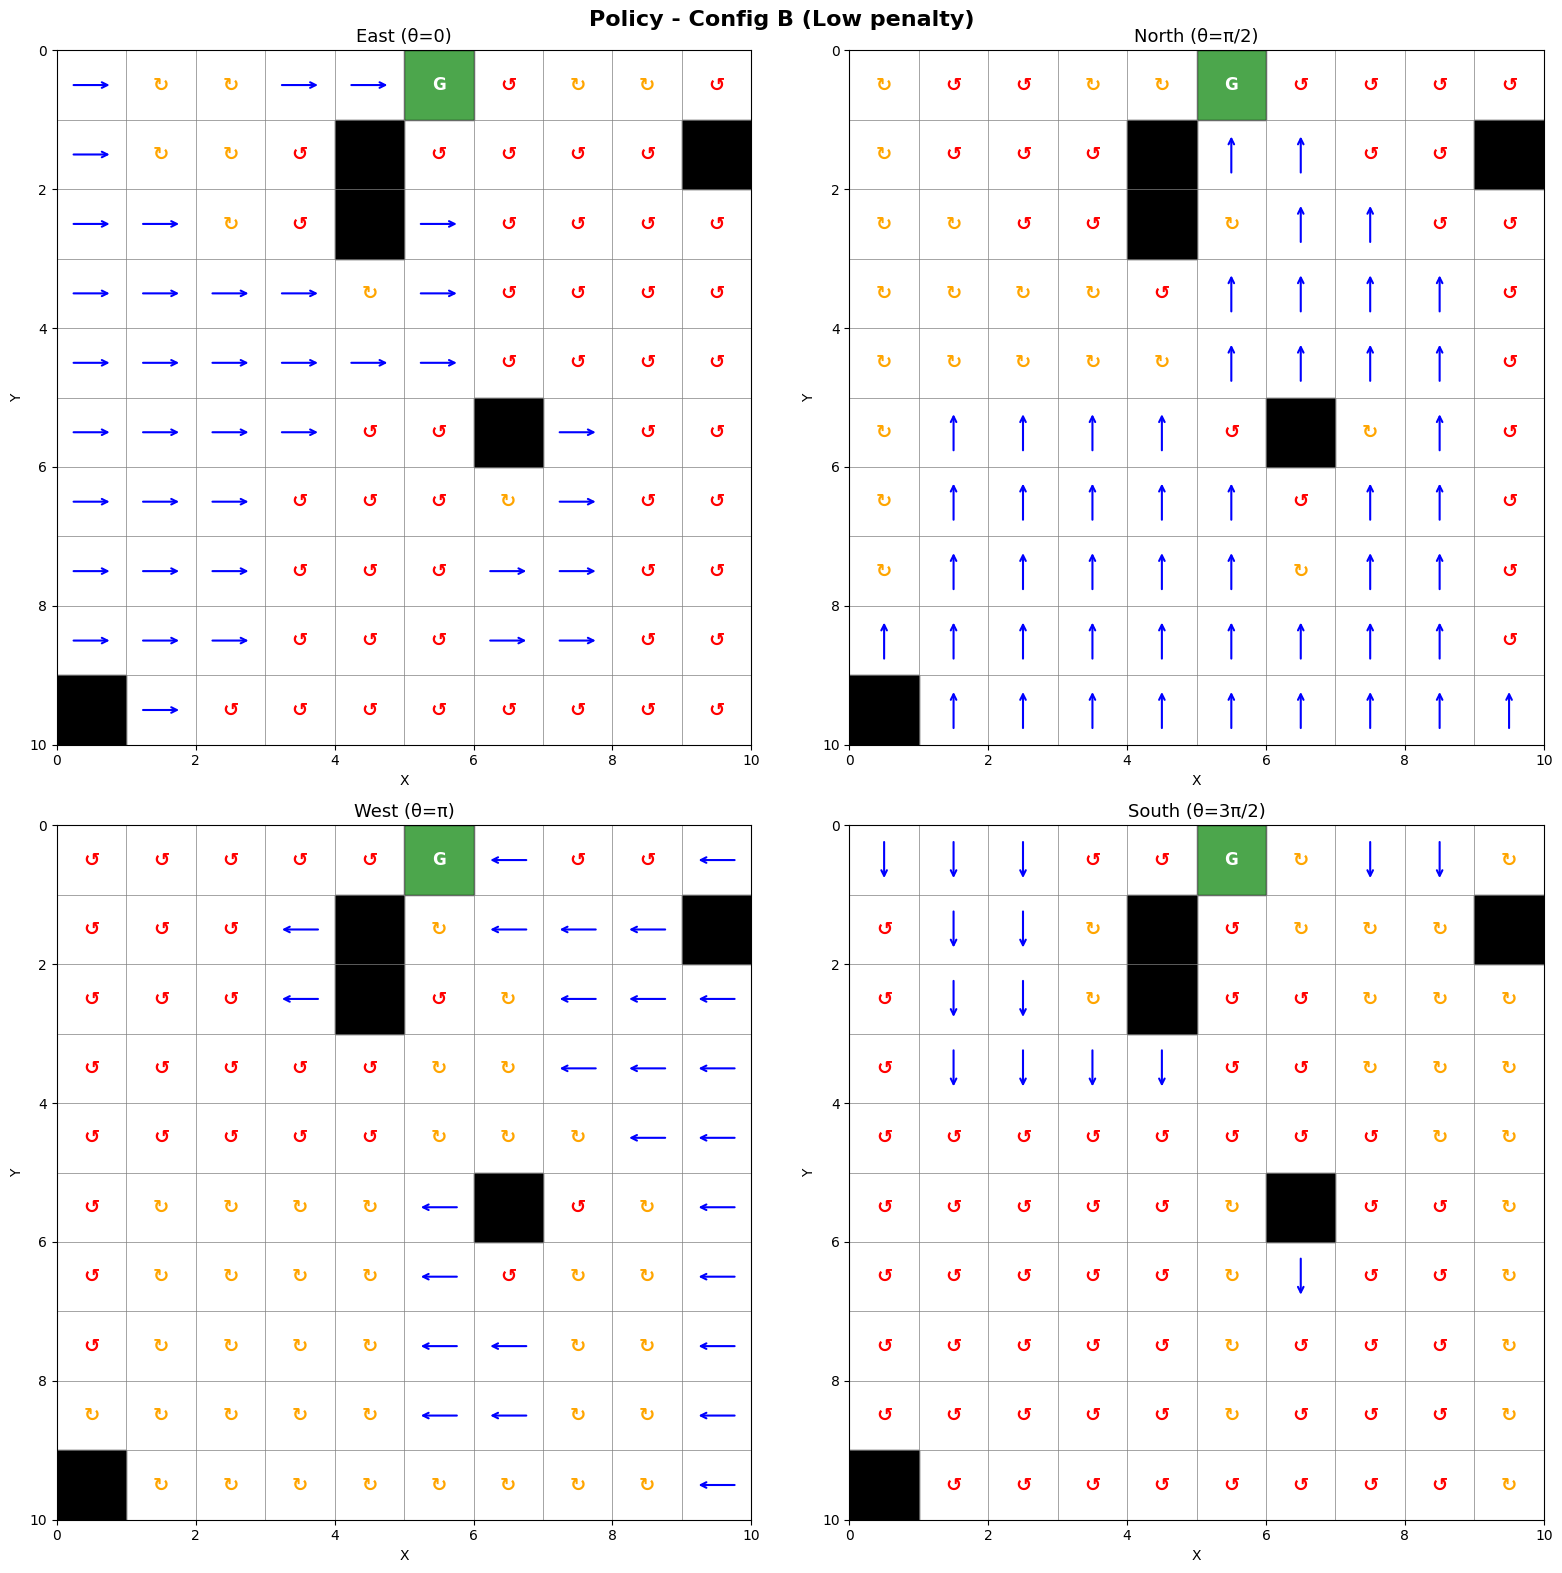

Saved: policy_config_b_(low_penalty).png


REWARD STRUCTURE COMPARISON TABLE
Config                         |   VI Iters |    VI Time |   VI Mem(KB) |   PI Iters |    PI Time |   PI Mem(KB)
----------------------------------------------------------------------------------------------------
Original                       |         17 |     0.2841 |       144.38 |         14 |     0.7540 |       207.47
Config A (High penalty)        |         24 |     0.3192 |       145.47 |         11 |     0.9935 |       207.41
Config B (Low penalty)         |         29 |     0.5604 |       144.49 |         12 |     1.1303 |       207.36


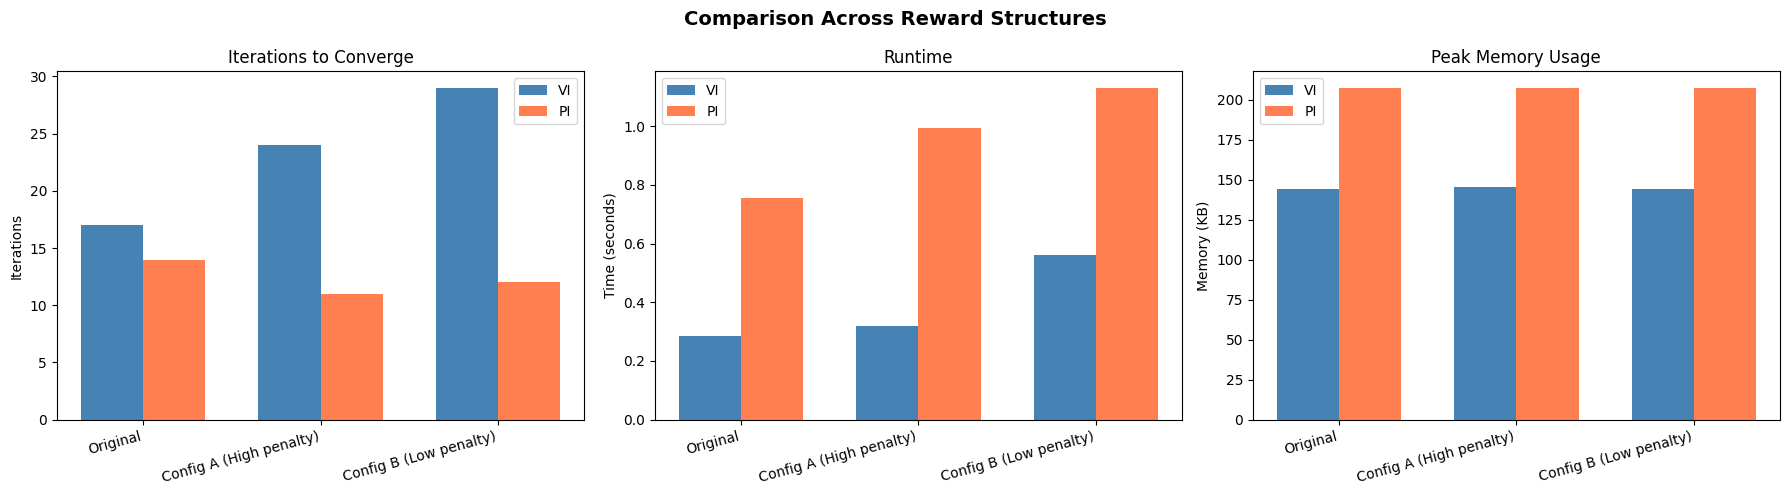

Saved: reward_comparison.png

(g) MONTE CARLO METHOD
  Episode 5000/100000, Avg V: -29.4055
  Episode 10000/100000, Avg V: -28.9711
  Episode 15000/100000, Avg V: -27.8515
  Episode 20000/100000, Avg V: -27.2891
  Episode 25000/100000, Avg V: -27.0901
  Episode 30000/100000, Avg V: -26.8934
  Episode 35000/100000, Avg V: -26.8364
  Episode 40000/100000, Avg V: -26.8745
  Episode 45000/100000, Avg V: -26.8430
  Episode 50000/100000, Avg V: -26.7635
  Episode 55000/100000, Avg V: -26.6963
  Episode 60000/100000, Avg V: -26.6782
  Episode 65000/100000, Avg V: -26.6938
  Episode 70000/100000, Avg V: -26.5366
  Episode 75000/100000, Avg V: -26.3547
  Episode 80000/100000, Avg V: -26.1272
  Episode 85000/100000, Avg V: -25.9902
  Episode 90000/100000, Avg V: -25.8898
  Episode 95000/100000, Avg V: -25.8088
  Episode 100000/100000, Avg V: -25.7444

=== MONTE CARLO (Exploring Starts) ===
Episodes: 100000
Runtime: 3535.2164 seconds
Peak memory: 10928.90 KB


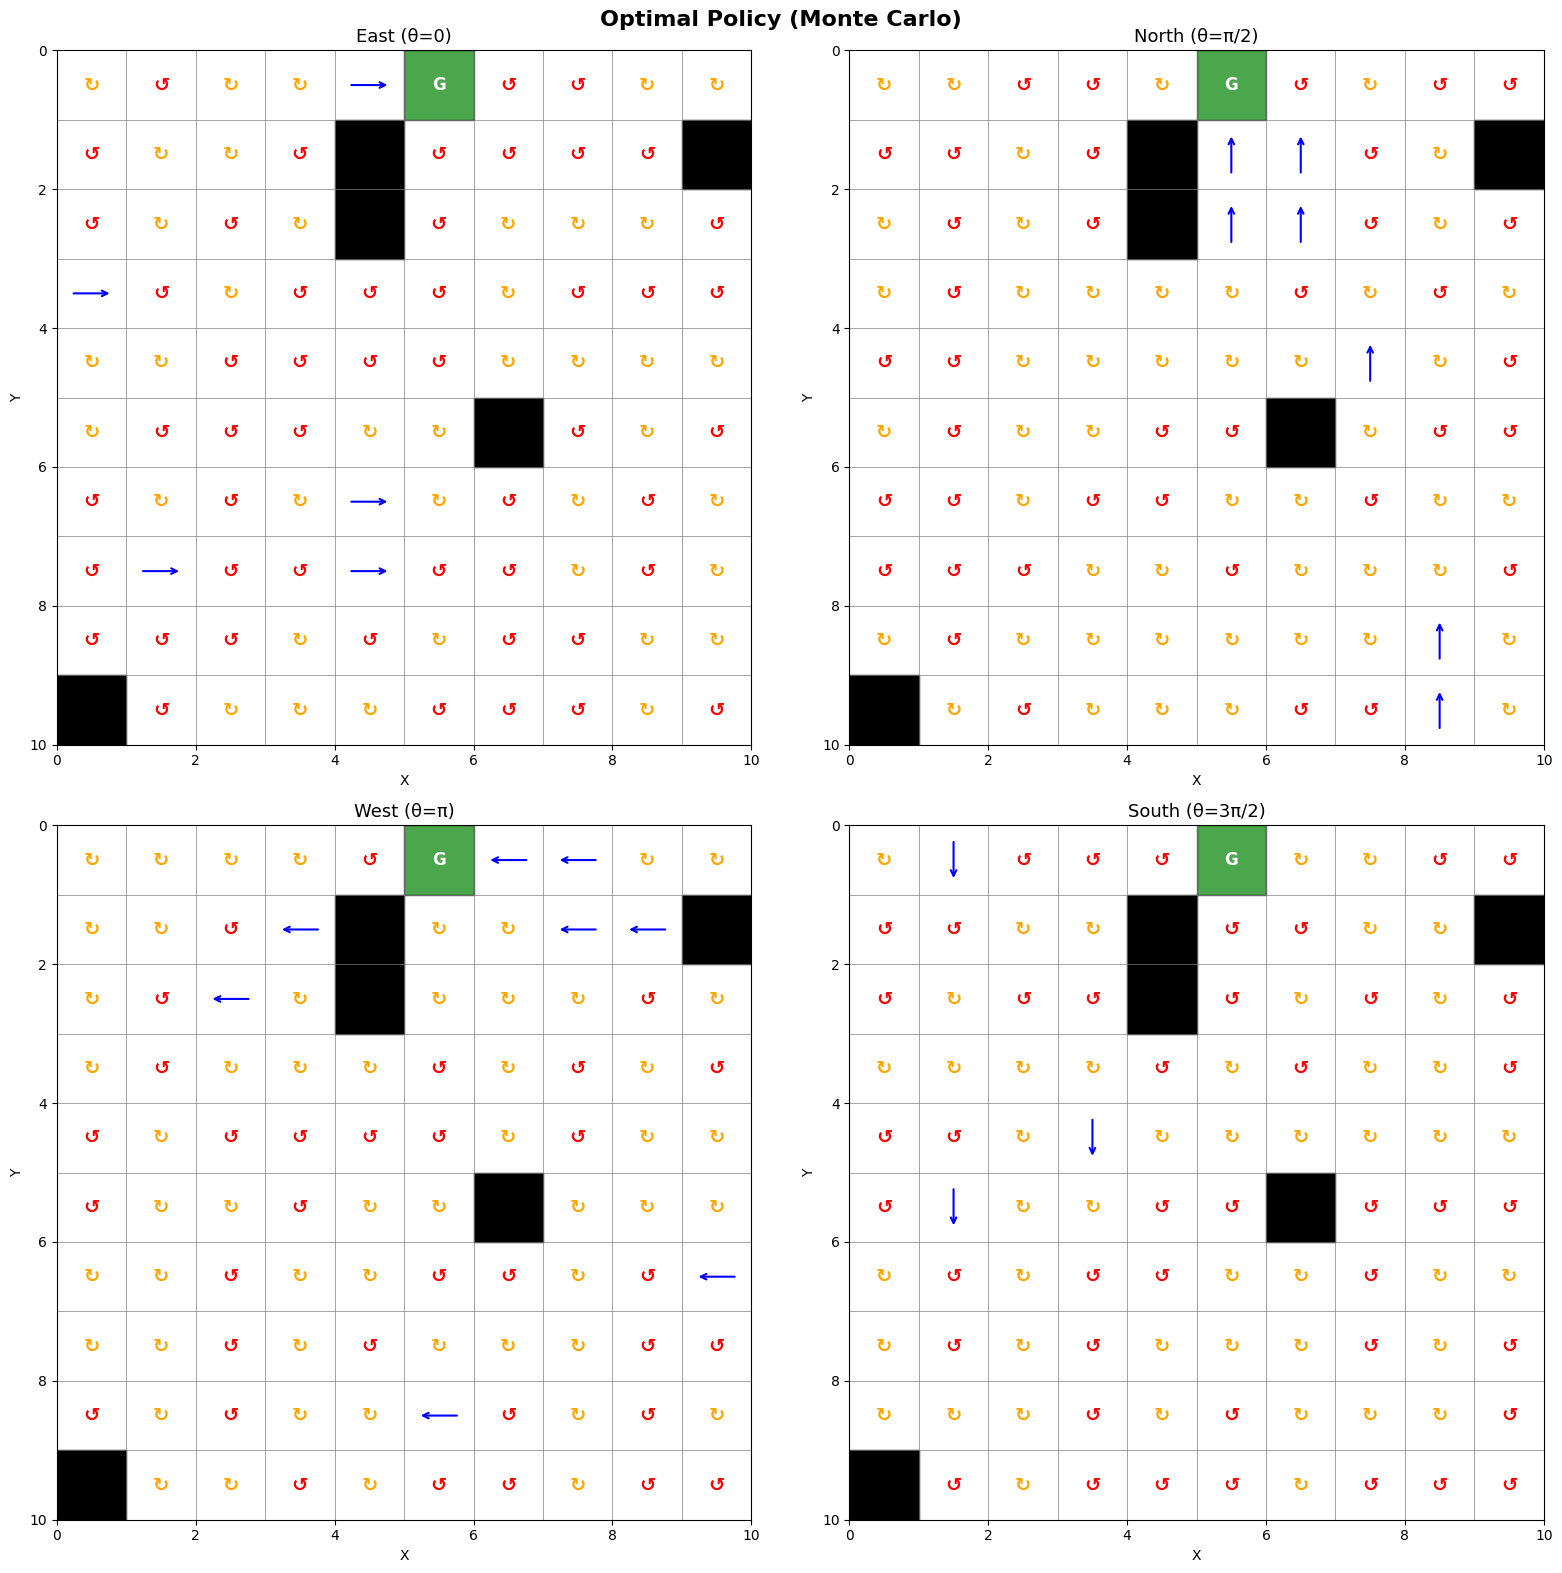

Saved: policy_mc.png


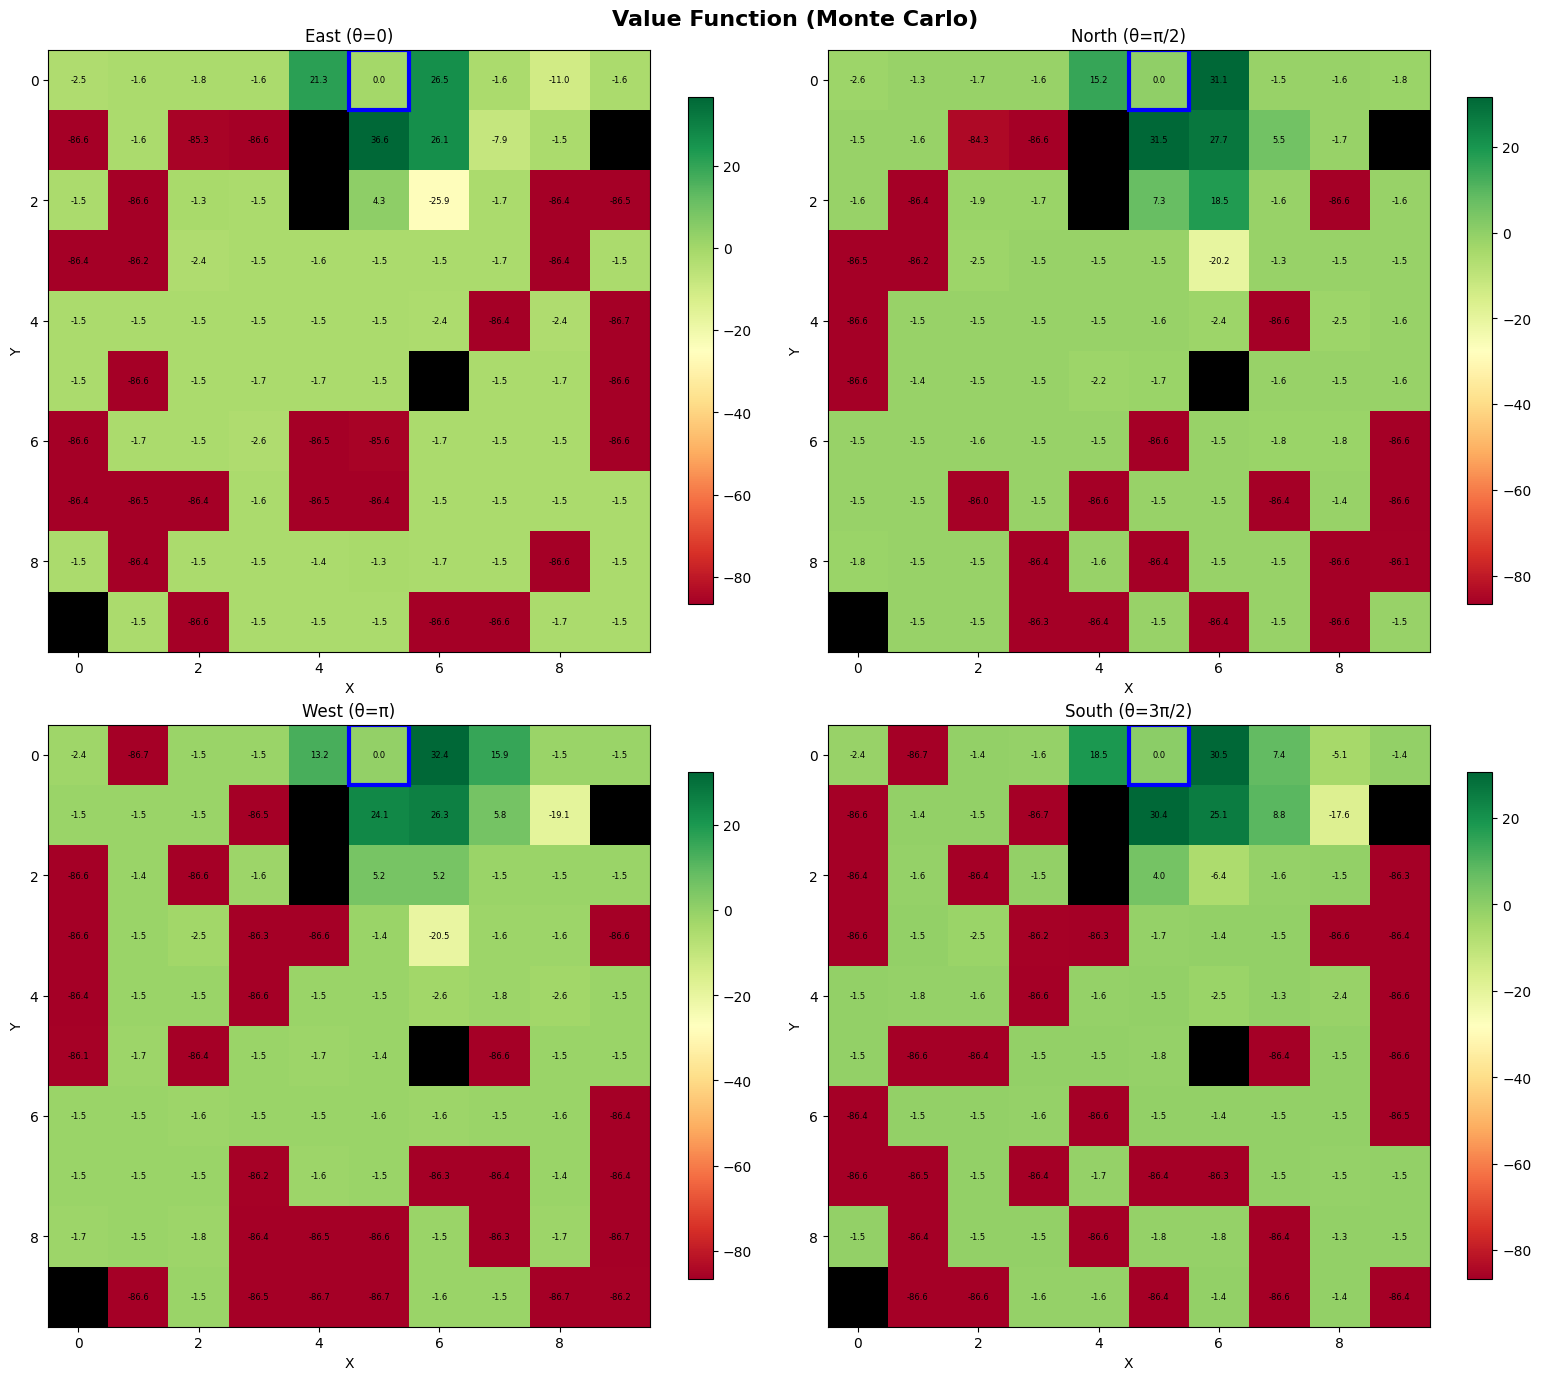

Saved: value_function_mc.png


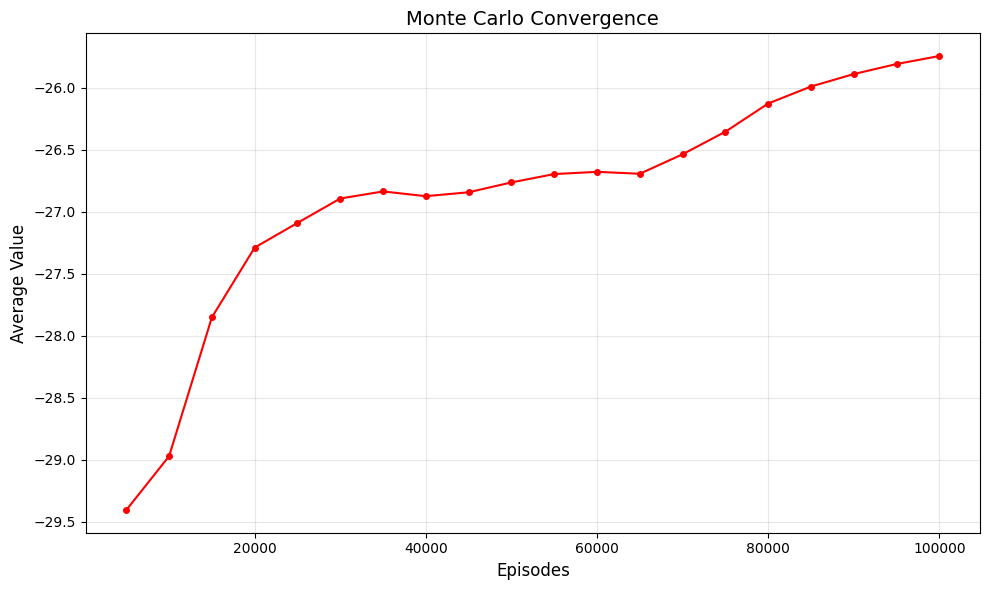

Saved: convergence_mc.png

    ┌─────────────────────────┬──────────────────┬──────────────────┬──────────────────┐
    │ Metric                  │ Value Iteration  │ Policy Iteration │ Monte Carlo      │
    ├─────────────────────────┼──────────────────┼──────────────────┼──────────────────┤
    │ Iterations/Episodes     │               17 │               11 │           100000 │
    │ Runtime (seconds)       │           0.3601 │           0.6668 │        3535.2164 │
    │ Peak Memory (KB)        │           141.16 │           209.92 │         10928.90 │
    │ Policy match with VI    │       -          │        324/400   │        145/400   │
    │ Mean |V - V_VI|         │       -          │         4.651889 │        31.623121 │
    └─────────────────────────┴──────────────────┴──────────────────┴──────────────────┘
    


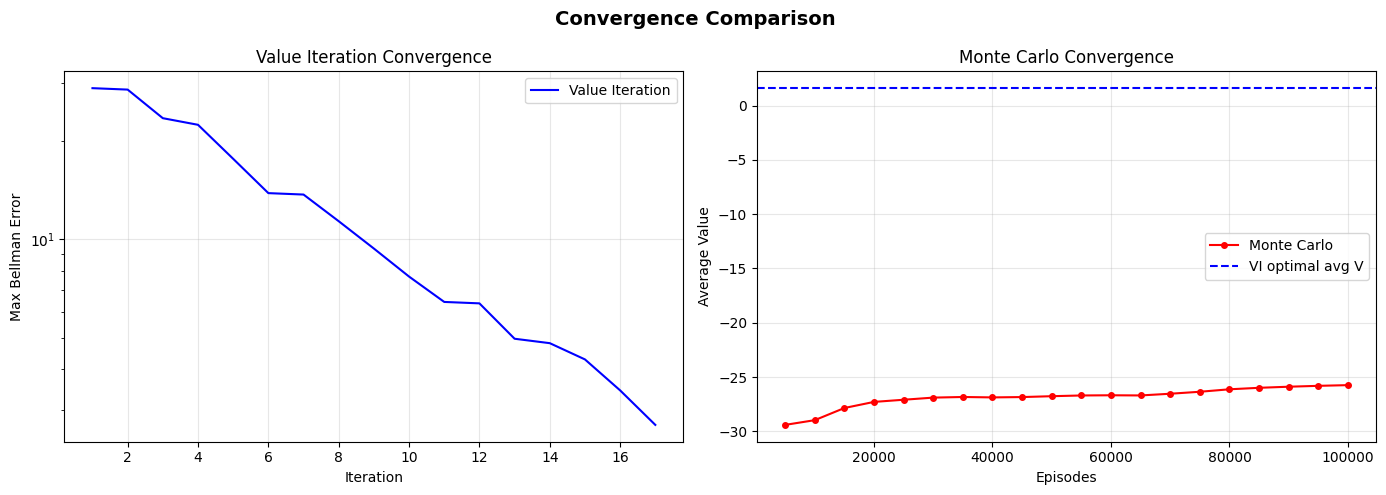

Saved: convergence_comparison.png

SUMMARY OF ALL GENERATED FILES

    Figures generated:
    1. grid_environment.png          - Grid with obstacles and goal
    2. convergence_vi.png            - Value Iteration convergence plot
    3. policy_vi.png                 - Optimal policy (VI) with arrows
    4. value_function_vi.png         - Value function heatmap (VI)
    5. policy_pi.png                 - Optimal policy (PI) with arrows
    6. value_function_pi.png         - Value function heatmap (PI)
    7. policy_comparison.png         - Side-by-side VI vs PI policies
    8. reward_comparison.png         - Reward structure comparison bar charts
    9. policy_mc.png                 - Monte Carlo policy
    10. value_function_mc.png        - Monte Carlo value function
    11. convergence_mc.png           - Monte Carlo convergence
    12. convergence_comparison.png   - Combined convergence comparison
    


In [ ]:
import numpy as np
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import copy

# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================

class DifferentialDriveRobotMDP:
    """
    Differential-Drive Robot MDP on a 10x10 grid.
    State: (x, y, theta_index) where theta_index in {0,1,2,3}
    corresponds to theta in {0, pi/2, pi, 3pi/2}
    Actions: Forward(0), TurnLeft(1), TurnRight(2)
    """

    def __init__(self, grid_size=10, obstacles=None, goal=None, seed=42):
        self.grid_size = grid_size
        self.orientations = [0, 1, 2, 3]  # 0=East(0), 1=North(pi/2), 2=West(pi), 3=South(3pi/2)
        self.orientation_names = ['East(0)', 'North(π/2)', 'West(π)', 'South(3π/2)']
        self.actions = [0, 1, 2]  # Forward, TurnLeft, TurnRight
        self.action_names = ['Forward', 'TurnLeft', 'TurnRight']
        self.gamma = 0.99  # Discount factor

        # Rewards
        self.step_reward = -1
        self.collision_reward = -100
        self.goal_reward = 50

        # Direction vectors for each orientation: East, North, West, South
        # East: +x, North: +y (we use row=y increasing downward, so North means y-1)
        # Let's use standard: East=(+1,0), North=(0,-1), West=(-1,0), South=(0,+1)
        self.dx = [1, 0, -1, 0]   # East, North, West, South
        self.dy = [0, -1, 0, 1]

        # Sideways directions (left and right relative to orientation)
        # For orientation 0 (East): left=North, right=South
        # For orientation 1 (North): left=West, right=East
        # For orientation 2 (West): left=South, right=North
        # For orientation 3 (South): left=East, right=West
        self.left_orientation = [1, 2, 3, 0]   # left relative direction index
        self.right_orientation = [3, 0, 1, 2]  # right relative direction index

        random.seed(seed)
        np.random.seed(seed)

        # Place obstacles randomly
        if obstacles is None:
            all_cells = [(x, y) for x in range(grid_size) for y in range(grid_size)]
            random.shuffle(all_cells)
            self.obstacles = set()
            idx = 0
            while len(self.obstacles) < 5:
                cell = all_cells[idx]
                idx += 1
                self.obstacles.add(cell)
        else:
            self.obstacles = set(obstacles)

        # Place goal (not on obstacle)
        if goal is None:
            for cell in all_cells[idx:]:
                if cell not in self.obstacles:
                    self.goal = cell
                    break
        else:
            self.goal = goal

        # Remove goal from obstacles if accidentally placed there
        self.obstacles.discard(self.goal)

        # Build state space
        self.states = []
        self.terminal_state = 'TERMINAL'
        for x in range(grid_size):
            for y in range(grid_size):
                for theta in self.orientations:
                    self.states.append((x, y, theta))

        self.state_index = {s: i for i, s in enumerate(self.states)}
        self.n_states = len(self.states)
        self.n_actions = len(self.actions)

        print(f"Grid Size: {grid_size}x{grid_size}")
        print(f"Obstacles: {sorted(self.obstacles)}")
        print(f"Goal: {self.goal}")
        print(f"Number of states: {self.n_states} + terminal")
        print(f"Number of actions: {self.n_actions}")

        # Precompute transitions
        self._build_transitions()

    def _is_valid(self, x, y):
        """Check if (x,y) is within bounds and not an obstacle."""
        return 0 <= x < self.grid_size and 0 <= y < self.grid_size and (x, y) not in self.obstacles

    def _build_transitions(self):
        """
        Build transition dictionary.
        transitions[state][action] = list of (probability, next_state, reward, done)
        """
        self.transitions = {}

        for s in self.states:
            x, y, theta = s
            self.transitions[s] = {}

            # Check if current state is on obstacle or goal (shouldn't happen in normal states)
            if (x, y) in self.obstacles:
                for a in self.actions:
                    self.transitions[s][a] = [(1.0, self.terminal_state, 0, True)]
                continue

            if (x, y) == self.goal:
                for a in self.actions:
                    self.transitions[s][a] = [(1.0, self.terminal_state, 0, True)]
                continue

            for a in self.actions:
                if a == 0:  # Forward
                    outcomes = []

                    # Main direction (forward): probability 0.8
                    nx_f, ny_f = x + self.dx[theta], y + self.dy[theta]
                    # Left slip: probability 0.1
                    left_dir = self.left_orientation[theta]
                    nx_l, ny_l = x + self.dx[left_dir], y + self.dy[left_dir]
                    # Right slip: probability 0.1
                    right_dir = self.right_orientation[theta]
                    nx_r, ny_r = x + self.dx[right_dir], y + self.dy[right_dir]

                    for prob, nx, ny in [(0.8, nx_f, ny_f), (0.1, nx_l, ny_l), (0.1, nx_r, ny_r)]:
                        if not (0 <= nx < self.grid_size and 0 <= ny < self.grid_size):
                            # Collision with boundary
                            outcomes.append((prob, self.terminal_state, self.step_reward + self.collision_reward, True))
                        elif (nx, ny) in self.obstacles:
                            # Collision with obstacle
                            outcomes.append((prob, self.terminal_state, self.step_reward + self.collision_reward, True))
                        elif (nx, ny) == self.goal:
                            # Reached goal
                            outcomes.append((prob, self.terminal_state, self.step_reward + self.goal_reward, True))
                        else:
                            outcomes.append((prob, (nx, ny, theta), self.step_reward, False))

                    # Merge outcomes with same next_state
                    merged = {}
                    for prob, ns, r, d in outcomes:
                        key = (ns, r, d)
                        if key in merged:
                            merged[key] += prob
                        else:
                            merged[key] = prob

                    self.transitions[s][a] = [(p, ns, r, d) for (ns, r, d), p in merged.items()]

                elif a == 1:  # TurnLeft (deterministic)
                    new_theta = (theta + 1) % 4
                    self.transitions[s][a] = [(1.0, (x, y, new_theta), self.step_reward, False)]

                elif a == 2:  # TurnRight (deterministic)
                    new_theta = (theta - 1) % 4
                    self.transitions[s][a] = [(1.0, (x, y, new_theta), self.step_reward, False)]

    def get_transitions(self, state, action):
        """Return list of (prob, next_state, reward, done)."""
        if state == self.terminal_state:
            return [(1.0, self.terminal_state, 0, True)]
        return self.transitions[state][action]


# ============================================================================
# VALUE ITERATION
# ============================================================================

def value_iteration(mdp, gamma=0.99, theta=1e-6, max_iterations=1000, record_first_n=3):
    """
    Value Iteration algorithm.
    Returns: V, policy, iterations, runtime, history of first N iterations
    """
    tracemalloc.start()
    start_time = time.time()

    # Initialize value function
    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    history = []  # Store first few iterations
    deltas = []

    for iteration in range(1, max_iterations + 1):
        delta = 0
        V_new = {}

        for s in mdp.states:
            x, y, theta = s
            # Skip if on goal or obstacle (terminal)
            if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
                V_new[s] = 0.0
                continue

            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(s, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + gamma * V[ns])
                action_values.append(q_val)

            V_new[s] = max(action_values)
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        V[mdp.terminal_state] = 0.0
        deltas.append(delta)

        if iteration <= record_first_n:
            history.append(copy.deepcopy(V))

        if delta < theta:
            break

    # Extract policy
    policy = {}
    for s in mdp.states:
        x, y, theta = s
        if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
            policy[s] = 0
            continue

        action_values = []
        for a in mdp.actions:
            q_val = 0.0
            for prob, ns, reward, done in mdp.get_transitions(s, a):
                if done:
                    q_val += prob * reward
                else:
                    q_val += prob * (reward + gamma * V[ns])
            action_values.append(q_val)
        policy[s] = int(np.argmax(action_values))

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024  # KB

    print(f"\n=== VALUE ITERATION ===")
    print(f"Converged in {iteration} iterations")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")
    print(f"Final delta: {delta:.8f}")

    return V, policy, iteration, runtime, memory_peak, history, deltas


# ============================================================================
# POLICY ITERATION
# ============================================================================

def policy_evaluation(mdp, policy, gamma=0.99, theta=1e-6, max_iterations=1000):
    """Evaluate a given policy."""
    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    for _ in range(max_iterations):
        delta = 0
        for s in mdp.states:
            x, y, theta = s
            if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
                continue

            a = policy[s]
            v_new = 0.0
            for prob, ns, reward, done in mdp.get_transitions(s, a):
                if done:
                    v_new += prob * reward
                else:
                    v_new += prob * (reward + gamma * V[ns])

            delta = max(delta, abs(v_new - V[s]))
            V[s] = v_new

        if delta < theta:
            break

    return V


def policy_iteration(mdp, gamma=0.99, max_iterations=100, record_first_n=3):
    """
    Policy Iteration algorithm.
    Returns: V, policy, iterations, runtime, history of first N iterations
    """
    tracemalloc.start()
    start_time = time.time()

    # Initialize random policy
    policy = {}
    for s in mdp.states:
        policy[s] = random.choice(mdp.actions)

    history = []
    iteration = 0

    for iteration in range(1, max_iterations + 1):
        # Policy Evaluation
        V = policy_evaluation(mdp, policy, gamma)

        if iteration <= record_first_n:
            history.append((copy.deepcopy(V), copy.deepcopy(policy)))

        # Policy Improvement
        policy_stable = True
        for s in mdp.states:
            x, y, theta = s
            if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
                continue

            old_action = policy[s]
            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(s, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + gamma * V[ns])
                action_values.append(q_val)

            policy[s] = int(np.argmax(action_values))
            if old_action != policy[s]:
                policy_stable = False

        if policy_stable:
            break

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024  # KB

    print(f"\n=== POLICY ITERATION ===")
    print(f"Converged in {iteration} iterations")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, iteration, runtime, memory_peak, history


# ============================================================================
# MONTE CARLO METHOD
# ============================================================================

def generate_episode(mdp, policy, start_state=None, max_steps=200):
    """Generate an episode following the given policy."""
    if start_state is None:
        # Random non-terminal start
        valid_starts = [s for s in mdp.states
                       if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles]
        state = random.choice(valid_starts)
    else:
        state = start_state

    episode = []
    for _ in range(max_steps):
        if state == mdp.terminal_state:
            break

        action = policy[state]
        transitions = mdp.get_transitions(state, action)
        probs = [t[0] for t in transitions]
        idx = np.random.choice(len(transitions), p=probs)
        prob, next_state, reward, done = transitions[idx]

        episode.append((state, action, reward))

        if done:
            break
        state = next_state

    return episode


def monte_carlo_exploring_starts(mdp, gamma=0.99, num_episodes=50000, record_interval=5000):
    """
    Monte Carlo with Exploring Starts for finding optimal policy.
    """
    tracemalloc.start()
    start_time = time.time()

    # Initialize
    Q = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns = defaultdict(list)

    # Initialize policy randomly
    policy = {}
    for s in mdp.states:
        policy[s] = random.choice(mdp.actions)

    value_history = []

    for ep in range(1, num_episodes + 1):
        # Exploring starts: random state and action
        valid_starts = [s for s in mdp.states
                       if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles]
        start_state = random.choice(valid_starts)
        start_action = random.choice(mdp.actions)

        # Generate episode with exploring start
        state = start_state
        action = start_action
        episode = []

        # First step with exploring start action
        transitions = mdp.get_transitions(state, action)
        probs = [t[0] for t in transitions]
        idx = np.random.choice(len(transitions), p=probs)
        prob, next_state, reward, done = transitions[idx]
        episode.append((state, action, reward))

        if not done:
            state = next_state
            # Continue with policy
            for _ in range(200):
                if state == mdp.terminal_state:
                    break
                action = policy[state]
                transitions = mdp.get_transitions(state, action)
                probs = [t[0] for t in transitions]
                idx = np.random.choice(len(transitions), p=probs)
                prob, next_state, reward, done = transitions[idx]
                episode.append((state, action, reward))
                if done:
                    break
                state = next_state

        # First-visit MC
        G = 0
        visited = set()
        for t in range(len(episode) - 1, -1, -1):
            s_t, a_t, r_t = episode[t]
            G = gamma * G + r_t

            sa = (s_t, a_t)
            if sa not in visited:
                visited.add(sa)
                returns[sa].append(G)
                Q[s_t][a_t] = np.mean(returns[sa])
                policy[s_t] = int(np.argmax(Q[s_t]))

        if ep % record_interval == 0:
            # Compute V from Q
            V = {}
            for s in mdp.states:
                if s in Q:
                    V[s] = np.max(Q[s])
                else:
                    V[s] = 0.0
            avg_v = np.mean([V[s] for s in mdp.states
                           if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles])
            value_history.append((ep, avg_v))
            print(f"  Episode {ep}/{num_episodes}, Avg V: {avg_v:.4f}")

    # Final V
    V = {}
    for s in mdp.states:
        x, y, theta = s
        if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
            V[s] = 0.0
        elif s in Q:
            V[s] = np.max(Q[s])
        else:
            V[s] = 0.0

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n=== MONTE CARLO (Exploring Starts) ===")
    print(f"Episodes: {num_episodes}")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, num_episodes, runtime, memory_peak, value_history


# ============================================================================
# EPSILON-GREEDY MONTE CARLO (Alternative)
# ============================================================================

def monte_carlo_epsilon_greedy(mdp, gamma=0.99, num_episodes=50000, epsilon=0.1, record_interval=5000):
    """
    On-policy first-visit MC with epsilon-greedy policy.
    """
    tracemalloc.start()
    start_time = time.time()

    Q = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns_count = defaultdict(lambda: np.zeros(mdp.n_actions))
    returns_sum = defaultdict(lambda: np.zeros(mdp.n_actions))

    value_history = []

    for ep in range(1, num_episodes + 1):
        # Generate episode with epsilon-greedy
        valid_starts = [s for s in mdp.states
                       if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles]
        state = random.choice(valid_starts)
        episode = []

        for _ in range(200):
            if state == mdp.terminal_state:
                break

            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = random.choice(mdp.actions)
            else:
                action = int(np.argmax(Q[state]))

            transitions = mdp.get_transitions(state, action)
            probs = [t[0] for t in transitions]
            idx = np.random.choice(len(transitions), p=probs)
            prob, next_state, reward, done = transitions[idx]
            episode.append((state, action, reward))

            if done:
                break
            state = next_state

        # First-visit MC update
        G = 0
        visited = set()
        for t in range(len(episode) - 1, -1, -1):
            s_t, a_t, r_t = episode[t]
            G = gamma * G + r_t

            sa = (s_t, a_t)
            if sa not in visited:
                visited.add(sa)
                returns_sum[s_t][a_t] += G
                returns_count[s_t][a_t] += 1
                Q[s_t][a_t] = returns_sum[s_t][a_t] / returns_count[s_t][a_t]

        if ep % record_interval == 0:
            V = {}
            for s in mdp.states:
                if s in Q:
                    V[s] = np.max(Q[s])
                else:
                    V[s] = 0.0
            avg_v = np.mean([V[s] for s in mdp.states
                           if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles])
            value_history.append((ep, avg_v))

    # Extract greedy policy
    policy = {}
    V = {}
    for s in mdp.states:
        x, y, theta = s
        if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
            policy[s] = 0
            V[s] = 0.0
        else:
            policy[s] = int(np.argmax(Q[s]))
            V[s] = np.max(Q[s])

    end_time = time.time()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_peak = peak / 1024

    print(f"\n=== MONTE CARLO (Epsilon-Greedy) ===")
    print(f"Episodes: {num_episodes}")
    print(f"Runtime: {runtime:.4f} seconds")
    print(f"Peak memory: {memory_peak:.2f} KB")

    return V, policy, num_episodes, runtime, memory_peak, value_history


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def visualize_grid(mdp, title="Grid Environment"):
    """Visualize the grid with obstacles and goal."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Draw grid
    for x in range(mdp.grid_size + 1):
        ax.axhline(y=x, color='gray', linewidth=0.5)
        ax.axvline(x=x, color='gray', linewidth=0.5)

    # Draw obstacles
    for (ox, oy) in mdp.obstacles:
        rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black', edgecolor='black')
        ax.add_patch(rect)

    # Draw goal
    gx, gy = mdp.goal
    rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.7)
    ax.add_patch(rect)
    ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    ax.set_xlim(0, mdp.grid_size)
    ax.set_ylim(0, mdp.grid_size)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    plt.tight_layout()
    plt.savefig('grid_environment.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: grid_environment.png")


def visualize_policy(mdp, policy, title="Policy Visualization", filename="policy.png"):
    """Visualize policy with orientation-aware arrows."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))

    orientation_labels = ['East (θ=0)', 'North (θ=π/2)', 'West (θ=π)', 'South (θ=3π/2)']

    # Arrow directions for each action given current orientation
    # Action 0 (Forward): arrow in direction of current orientation
    # Action 1 (TurnLeft): curved arrow
    # Action 2 (TurnRight): curved arrow

    # For Forward action, arrow direction based on orientation:
    # East: →, North: ↑, West: ←, South: ↓
    arrow_dx = [0.3, 0, -0.3, 0]    # For Forward in each orientation
    arrow_dy = [0, -0.3, 0, 0.3]

    for theta_idx in range(4):
        ax = axes[theta_idx // 2][theta_idx % 2]

        # Draw grid
        for x in range(mdp.grid_size + 1):
            ax.axhline(y=x, color='gray', linewidth=0.5)
            ax.axvline(x=x, color='gray', linewidth=0.5)

        # Draw obstacles
        for (ox, oy) in mdp.obstacles:
            rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black', edgecolor='black')
            ax.add_patch(rect)

        # Draw goal
        gx, gy = mdp.goal
        rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.7)
        ax.add_patch(rect)
        ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=12,
                fontweight='bold', color='white')

        # Draw policy arrows
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                if (x, y) in mdp.obstacles or (x, y) == mdp.goal:
                    continue

                s = (x, y, theta_idx)
                a = policy[s]

                cx, cy = x + 0.5, y + 0.5

                if a == 0:  # Forward
                    dx, dy = arrow_dx[theta_idx], arrow_dy[theta_idx]
                    ax.annotate('', xy=(cx + dx, cy + dy), xytext=(cx - dx, cy - dy),
                              arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
                elif a == 1:  # TurnLeft
                    ax.annotate('↺', xy=(cx, cy), fontsize=14, ha='center', va='center',
                              color='red', fontweight='bold')
                elif a == 2:  # TurnRight
                    ax.annotate('↻', xy=(cx, cy), fontsize=14, ha='center', va='center',
                              color='orange', fontweight='bold')

        ax.set_xlim(0, mdp.grid_size)
        ax.set_ylim(0, mdp.grid_size)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_title(f'{orientation_labels[theta_idx]}', fontsize=13)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def visualize_value_function(mdp, V, title="Value Function", filename="value_function.png"):
    """Visualize value function as heatmap for each orientation."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    orientation_labels = ['East (θ=0)', 'North (θ=π/2)', 'West (θ=π)', 'South (θ=3π/2)']

    for theta_idx in range(4):
        ax = axes[theta_idx // 2][theta_idx % 2]

        grid = np.zeros((mdp.grid_size, mdp.grid_size))
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                s = (x, y, theta_idx)
                grid[y][x] = V.get(s, 0)

        # Mark obstacles as NaN
        mask = np.zeros_like(grid, dtype=bool)
        for (ox, oy) in mdp.obstacles:
            mask[oy][ox] = True

        masked_grid = np.ma.array(grid, mask=mask)

        im = ax.imshow(masked_grid, cmap='RdYlGn', interpolation='nearest')
        plt.colorbar(im, ax=ax, shrink=0.8)

        # Mark obstacles
        for (ox, oy) in mdp.obstacles:
            rect = plt.Rectangle((ox - 0.5, oy - 0.5), 1, 1, facecolor='black')
            ax.add_patch(rect)

        # Mark goal
        gx, gy = mdp.goal
        rect = plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1, facecolor='none', edgecolor='blue', linewidth=3)
        ax.add_patch(rect)

        # Add value text
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                if (x, y) not in mdp.obstacles:
                    ax.text(x, y, f'{grid[y][x]:.1f}', ha='center', va='center', fontsize=6)

        ax.set_title(f'{orientation_labels[theta_idx]}', fontsize=12)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_convergence(deltas, title="Value Iteration Convergence", filename="convergence_vi.png"):
    """Plot convergence curve."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(1, len(deltas) + 1), deltas, 'b-', linewidth=1.5)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Max Delta (Bellman Error)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


def plot_mc_convergence(value_history, title="Monte Carlo Convergence", filename="convergence_mc.png"):
    """Plot MC convergence."""
    episodes = [v[0] for v in value_history]
    avg_values = [v[1] for v in value_history]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(episodes, avg_values, 'r-o', linewidth=1.5, markersize=4)
    ax.set_xlabel('Episodes', fontsize=12)
    ax.set_ylabel('Average Value', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ============================================================================
# PRINT UTILITIES FOR REPORT
# ============================================================================

def print_value_table(mdp, V, theta_idx, title=""):
    """Print value function for a specific orientation as a table."""
    print(f"\n{title} (θ={theta_idx}):")
    print("-" * 80)
    header = "y\\x | " + " | ".join([f"  {x}  " for x in range(mdp.grid_size)])
    print(header)
    print("-" * 80)
    for y in range(mdp.grid_size):
        row = f" {y}  | "
        for x in range(mdp.grid_size):
            if (x, y) in mdp.obstacles:
                row += " OBS  | "
            elif (x, y) == mdp.goal:
                row += " GOAL | "
            else:
                s = (x, y, theta_idx)
                row += f"{V.get(s, 0):6.2f}| "
        print(row)
    print("-" * 80)


def print_policy_table(mdp, policy, theta_idx, title=""):
    """Print policy for a specific orientation."""
    action_symbols = ['F', 'L', 'R']  # Forward, Left, Right
    print(f"\n{title} (θ={theta_idx}):")
    print("-" * 60)
    for y in range(mdp.grid_size):
        row = f" {y}  | "
        for x in range(mdp.grid_size):
            if (x, y) in mdp.obstacles:
                row += " X | "
            elif (x, y) == mdp.goal:
                row += " G | "
            else:
                s = (x, y, theta_idx)
                row += f" {action_symbols[policy[s]]} | "
        print(row)
    print("-" * 60)


def print_first_iterations_vi(mdp, history, n=3):
    """Print first N iterations of Value Iteration for hand calculation comparison."""
    print("\n" + "=" * 80)
    print("FIRST 3 ITERATIONS OF VALUE ITERATION (for hand-calculation comparison)")
    print("=" * 80)
    print("Showing values for orientation θ=0 (East) only for brevity")
    print("(Full tables available for all orientations)\n")

    for i, V in enumerate(history[:n]):
        print(f"\n--- Iteration {i+1} ---")
        print_value_table(mdp, V, theta_idx=0, title=f"V after iteration {i+1}")


def print_first_iterations_pi(mdp, history, n=3):
    """Print first N iterations of Policy Iteration."""
    print("\n" + "=" * 80)
    print("FIRST 3 ITERATIONS OF POLICY ITERATION (for hand-calculation comparison)")
    print("=" * 80)
    print("Showing for orientation θ=0 (East) only for brevity\n")

    for i, (V, pol) in enumerate(history[:n]):
        print(f"\n--- Iteration {i+1} ---")
        print_value_table(mdp, V, theta_idx=0, title=f"V after iteration {i+1}")
        print_policy_table(mdp, pol, theta_idx=0, title=f"Policy after iteration {i+1}")


# ============================================================================
# HAND CALCULATION HELPER
# ============================================================================

def hand_calculation_example(mdp):
    """
    Show detailed hand calculation for first 3 iterations of VI
    for a few selected states.
    """
    print("\n" + "=" * 80)
    print("HAND CALCULATION EXAMPLE")
    print("=" * 80)

    # Pick a state near the goal for demonstration
    gx, gy = mdp.goal

    # Find a valid state adjacent to goal
    example_states = []
    for dx, dy in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
        nx, ny = gx + dx, gy + dy
        if 0 <= nx < mdp.grid_size and 0 <= ny < mdp.grid_size and (nx, ny) not in mdp.obstacles:
            example_states.append((nx, ny))
            break

    if not example_states:
        # Use any valid state
        for x in range(mdp.grid_size):
            for y in range(mdp.grid_size):
                if (x, y) not in mdp.obstacles and (x, y) != mdp.goal:
                    example_states.append((x, y))
                    break
            if example_states:
                break

    ex, ey = example_states[0]

    print(f"\nGoal: {mdp.goal}")
    print(f"Example state for hand calculation: ({ex}, {ey}, θ=0 [East])")
    print(f"Step reward: {mdp.step_reward}, Collision reward: {mdp.collision_reward}, Goal reward: {mdp.goal_reward}")
    print(f"Discount factor γ = {mdp.gamma}")

    print(f"\n--- Initialization ---")
    print(f"V₀(s) = 0 for all states")

    # Iteration 1
    print(f"\n--- Iteration 1 ---")
    print(f"For state ({ex}, {ey}, 0):")

    s = (ex, ey, 0)
    for a in mdp.actions:
        print(f"\n  Action: {mdp.action_names[a]}")
        q_val = 0.0
        for prob, ns, reward, done in mdp.get_transitions(s, a):
            if done:
                contrib = prob * reward
                print(f"    P={prob:.1f}: next={ns}, R={reward}, terminal → contribution = {prob}×{reward} = {contrib:.2f}")
            else:
                contrib = prob * (reward + mdp.gamma * 0.0)  # V₀ = 0
                print(f"    P={prob:.1f}: next={ns}, R={reward} + γ×V₀({ns})={mdp.gamma}×0 → contribution = {prob}×({reward}+0) = {contrib:.2f}")
            q_val += contrib
        print(f"  Q(s, {mdp.action_names[a]}) = {q_val:.4f}")

    # Compute actual values
    V = {s: 0.0 for s in mdp.states}
    V[mdp.terminal_state] = 0.0

    for iteration in range(1, 4):
        V_new = {}
        for state in mdp.states:
            x, y, theta = state
            if (x, y) == mdp.goal or (x, y) in mdp.obstacles:
                V_new[state] = 0.0
                continue

            action_values = []
            for a in mdp.actions:
                q_val = 0.0
                for prob, ns, reward, done in mdp.get_transitions(state, a):
                    if done:
                        q_val += prob * reward
                    else:
                        q_val += prob * (reward + mdp.gamma * V[ns])
                action_values.append(q_val)
            V_new[state] = max(action_values)

        V = V_new
        V[mdp.terminal_state] = 0.0

        print(f"\n  V_{iteration}({ex}, {ey}, 0) = {V.get(s, 0):.4f}")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    print("=" * 80)
    print("ECS 427/627: Multi-agent Reinforcement Learning - Assignment 1")
    print("Question 1: Differential-Drive Robot with Orientation-Dependent Planning")
    print("=" * 80)

    # ========================================================================
    # (a) MDP Formulation
    # ========================================================================
    print("\n" + "=" * 80)
    print("(a) MDP FORMULATION")
    print("=" * 80)

    mdp = DifferentialDriveRobotMDP(grid_size=10, seed=42)

    print(f"""
    MDP Formulation:
    ================
    States: S = {{(x, y, θ) | x ∈ [0,9], y ∈ [0,9], θ ∈ {{0, π/2, π, 3π/2}}}} ∪ {{TERMINAL}}
    Total non-terminal states: {mdp.n_states}

    Actions: A = {{Forward, TurnLeft, TurnRight}}

    Transition Model:
    - Forward:
        P(forward | s, Forward) = 0.8
        P(slip_left | s, Forward) = 0.1
        P(slip_right | s, Forward) = 0.1
    - TurnLeft: Deterministic, θ' = (θ + π/2) mod 2π
    - TurnRight: Deterministic, θ' = (θ - π/2) mod 2π
    - Collision → TERMINAL state

    Reward Structure:
    - Step cost: {mdp.step_reward}
    - Collision: {mdp.collision_reward} (terminal)
    - Goal reached: {mdp.goal_reward} (terminal)

    Discount Factor: γ = {mdp.gamma}

    Obstacles: {sorted(mdp.obstacles)}
    Goal: {mdp.goal}
    """)

    # Visualize grid
    visualize_grid(mdp, title="10×10 Grid Environment")

    # ========================================================================
    # Hand Calculation Example
    # ========================================================================
    hand_calculation_example(mdp)

    # ========================================================================
    # (b) Value Iteration
    # ========================================================================
    print("\n" + "=" * 80)
    print("(b) VALUE ITERATION")
    print("=" * 80)

    V_vi, policy_vi, iters_vi, time_vi, mem_vi, history_vi, deltas_vi = value_iteration(
        mdp, gamma=0.99, theta=1e-6
    )

    # Print first 3 iterations
    print_first_iterations_vi(mdp, history_vi, n=3)

    # Print optimal policy
    print("\n--- Optimal Policy (Value Iteration) ---")
    for theta_idx in range(4):
        print_policy_table(mdp, policy_vi, theta_idx,
                          title=f"Optimal Policy (VI)")

    # Visualizations
    plot_convergence(deltas_vi, "Value Iteration Convergence", "convergence_vi.png")
    visualize_policy(mdp, policy_vi, "Optimal Policy (Value Iteration)", "policy_vi.png")
    visualize_value_function(mdp, V_vi, "Value Function (Value Iteration)", "value_function_vi.png")

    # ========================================================================
    # (c) Policy Iteration
    # ========================================================================
    print("\n" + "=" * 80)
    print("(c) POLICY ITERATION")
    print("=" * 80)

    V_pi, policy_pi, iters_pi, time_pi, mem_pi, history_pi = policy_iteration(
        mdp, gamma=0.99
    )

    # Print first 3 iterations
    print_first_iterations_pi(mdp, history_pi, n=3)

    # Print optimal policy
    print("\n--- Optimal Policy (Policy Iteration) ---")
    for theta_idx in range(4):
        print_policy_table(mdp, policy_pi, theta_idx,
                          title=f"Optimal Policy (PI)")

    # Visualizations
    visualize_policy(mdp, policy_pi, "Optimal Policy (Policy Iteration)", "policy_pi.png")
    visualize_value_function(mdp, V_pi, "Value Function (Policy Iteration)", "value_function_pi.png")

    # ========================================================================
    # (d) Comparison: VI vs PI
    # ========================================================================
    print("\n" + "=" * 80)
    print("(d) COMPARISON: VALUE ITERATION vs POLICY ITERATION")
    print("=" * 80)

    # Check policy agreement
    policy_match = sum(1 for s in mdp.states if policy_vi[s] == policy_pi[s])

    print(f"""
    ┌─────────────────────┬──────────────────┬──────────────────┐
    │ Metric              │ Value Iteration  │ Policy Iteration │
    ├─────────────────────┼──────────────────┼──────────────────┤
    │ Iterations          │ {iters_vi:>16} │ {iters_pi:>16} │
    │ Runtime (seconds)   │ {time_vi:>16.4f} │ {time_pi:>16.4f} │
    │ Peak Memory (KB)    │ {mem_vi:>16.2f} │ {mem_pi:>16.2f} │
    │ Policy Agreement    │ {policy_match}/{len(mdp.states)} states match          │
    └─────────────────────┴──────────────────┴──────────────────┘
    """)

    # Value difference
    v_diff = [abs(V_vi.get(s, 0) - V_pi.get(s, 0)) for s in mdp.states]
    print(f"  Max value difference between VI and PI: {max(v_diff):.6f}")
    print(f"  Mean value difference: {np.mean(v_diff):.6f}")

    # ========================================================================
    # (e) Policy Visualization with orientation-aware arrows
    # ========================================================================
    print("\n" + "=" * 80)
    print("(e) POLICY VISUALIZATION (Orientation-Aware)")
    print("=" * 80)
    print("See saved figures: policy_vi.png, policy_pi.png")

    # Combined visualization
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))

    orientation_labels = ['East (θ=0)', 'North (θ=π/2)', 'West (θ=π)', 'South (θ=3π/2)']
    arrow_dx = [0.3, 0, -0.3, 0]
    arrow_dy = [0, -0.3, 0, 0.3]

    for row, (policy, method) in enumerate([(policy_vi, "Value Iteration"), (policy_pi, "Policy Iteration")]):
        for theta_idx in range(4):
            ax = axes[row][theta_idx]

            for x in range(mdp.grid_size + 1):
                ax.axhline(y=x, color='gray', linewidth=0.5)
                ax.axvline(x=x, color='gray', linewidth=0.5)

            for (ox, oy) in mdp.obstacles:
                rect = plt.Rectangle((ox, oy), 1, 1, facecolor='black', edgecolor='black')
                ax.add_patch(rect)

            gx, gy = mdp.goal
            rect = plt.Rectangle((gx, gy), 1, 1, facecolor='green', edgecolor='black', alpha=0.7)
            ax.add_patch(rect)
            ax.text(gx + 0.5, gy + 0.5, 'G', ha='center', va='center', fontsize=10, fontweight='bold', color='white')

            for x in range(mdp.grid_size):
                for y in range(mdp.grid_size):
                    if (x, y) in mdp.obstacles or (x, y) == mdp.goal:
                        continue

                    s = (x, y, theta_idx)
                    a = policy[s]
                    cx, cy = x + 0.5, y + 0.5

                    if a == 0:
                        dx, dy = arrow_dx[theta_idx], arrow_dy[theta_idx]
                        ax.annotate('', xy=(cx + dx, cy + dy), xytext=(cx - dx, cy - dy),
                                  arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
                    elif a == 1:
                        ax.annotate('↺', xy=(cx, cy), fontsize=12, ha='center', va='center', color='red')
                    elif a == 2:
                        ax.annotate('↻', xy=(cx, cy), fontsize=12, ha='center', va='center', color='orange')

            ax.set_xlim(0, mdp.grid_size)
            ax.set_ylim(0, mdp.grid_size)
            ax.set_aspect('equal')
            ax.invert_yaxis()
            ax.set_title(f'{method}\n{orientation_labels[theta_idx]}', fontsize=10)

    fig.suptitle('Policy Comparison: VI vs PI (All Orientations)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('policy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: policy_comparison.png")

    # ========================================================================
    # (f) Different Reward Structures
    # ========================================================================
    print("\n" + "=" * 80)
    print("(f) REWARD STRUCTURE COMPARISON")
    print("=" * 80)

    reward_configs = [
        {"name": "Original", "step": -1, "collision": -100, "goal": 50},
        {"name": "Config A (High penalty)", "step": -2, "collision": -200, "goal": 100},
        {"name": "Config B (Low penalty)", "step": -0.1, "collision": -50, "goal": 200},
    ]

    results_table = []

    for config in reward_configs:
        print(f"\n--- Reward Config: {config['name']} ---")
        print(f"    Step: {config['step']}, Collision: {config['collision']}, Goal: {config['goal']}")

        # Modify MDP rewards
        mdp_config = DifferentialDriveRobotMDP(grid_size=10,
                                                obstacles=list(mdp.obstacles),
                                                goal=mdp.goal,
                                                seed=42)
        mdp_config.step_reward = config['step']
        mdp_config.collision_reward = config['collision']
        mdp_config.goal_reward = config['goal']
        mdp_config._build_transitions()

        # Value Iteration
        V_c, pol_c, it_c, rt_c, mem_c, _, deltas_c = value_iteration(mdp_config, gamma=0.99)

        # Policy Iteration
        V_pc, pol_pc, it_pc, rt_pc, mem_pc, _ = policy_iteration(mdp_config, gamma=0.99)

        results_table.append({
            'config': config['name'],
            'vi_iters': it_c, 'vi_time': rt_c, 'vi_mem': mem_c,
            'pi_iters': it_pc, 'pi_time': rt_pc, 'pi_mem': mem_pc,
        })

        # Visualize policy for this config
        visualize_policy(mdp_config, pol_c,
                        f"Policy - {config['name']}",
                        f"policy_{config['name'].replace(' ', '_').lower()}.png")

    # Print comparison table
    print("\n\n" + "=" * 100)
    print("REWARD STRUCTURE COMPARISON TABLE")
    print("=" * 100)
    print(f"{'Config':<30} | {'VI Iters':>10} | {'VI Time':>10} | {'VI Mem(KB)':>12} | {'PI Iters':>10} | {'PI Time':>10} | {'PI Mem(KB)':>12}")
    print("-" * 100)
    for r in results_table:
        print(f"{r['config']:<30} | {r['vi_iters']:>10} | {r['vi_time']:>10.4f} | {r['vi_mem']:>12.2f} | {r['pi_iters']:>10} | {r['pi_time']:>10.4f} | {r['pi_mem']:>12.2f}")
    print("=" * 100)

    # Bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    configs = [r['config'] for r in results_table]
    x_pos = np.arange(len(configs))
    width = 0.35

    # Iterations
    vi_iters = [r['vi_iters'] for r in results_table]
    pi_iters = [r['pi_iters'] for r in results_table]
    axes[0].bar(x_pos - width/2, vi_iters, width, label='VI', color='steelblue')
    axes[0].bar(x_pos + width/2, pi_iters, width, label='PI', color='coral')
    axes[0].set_ylabel('Iterations')
    axes[0].set_title('Iterations to Converge')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(configs, rotation=15, ha='right')
    axes[0].legend()

    # Runtime
    vi_times = [r['vi_time'] for r in results_table]
    pi_times = [r['pi_time'] for r in results_table]
    axes[1].bar(x_pos - width/2, vi_times, width, label='VI', color='steelblue')
    axes[1].bar(x_pos + width/2, pi_times, width, label='PI', color='coral')
    axes[1].set_ylabel('Time (seconds)')
    axes[1].set_title('Runtime')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(configs, rotation=15, ha='right')
    axes[1].legend()

    # Memory
    vi_mems = [r['vi_mem'] for r in results_table]
    pi_mems = [r['pi_mem'] for r in results_table]
    axes[2].bar(x_pos - width/2, vi_mems, width, label='VI', color='steelblue')
    axes[2].bar(x_pos + width/2, pi_mems, width, label='PI', color='coral')
    axes[2].set_ylabel('Memory (KB)')
    axes[2].set_title('Peak Memory Usage')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(configs, rotation=15, ha='right')
    axes[2].legend()

    plt.suptitle('Comparison Across Reward Structures', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('reward_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: reward_comparison.png")

    # ========================================================================
    # (g) Monte Carlo Method
    # ========================================================================
    print("\n" + "=" * 80)
    print("(g) MONTE CARLO METHOD")
    print("=" * 80)

    V_mc, policy_mc, eps_mc, time_mc, mem_mc, mc_history = monte_carlo_exploring_starts(
        mdp, gamma=0.99, num_episodes=100000, record_interval=5000
    )

    # Visualize MC policy
    visualize_policy(mdp, policy_mc, "Optimal Policy (Monte Carlo)", "policy_mc.png")
    visualize_value_function(mdp, V_mc, "Value Function (Monte Carlo)", "value_function_mc.png")

    # MC convergence plot
    plot_mc_convergence(mc_history, "Monte Carlo Convergence", "convergence_mc.png")

    # Compare MC with VI and PI
    # Policy agreement
    mc_vi_match = sum(1 for s in mdp.states if policy_mc.get(s) == policy_vi.get(s))
    mc_pi_match = sum(1 for s in mdp.states if policy_mc.get(s) == policy_pi.get(s))

    # Value differences
    v_diff_mc_vi = [abs(V_mc.get(s, 0) - V_vi.get(s, 0)) for s in mdp.states
                    if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles]
    v_diff_mc_pi = [abs(V_mc.get(s, 0) - V_pi.get(s, 0)) for s in mdp.states
                    if (s[0], s[1]) != mdp.goal and (s[0], s[1]) not in mdp.obstacles]

    print(f"""
    ┌─────────────────────────┬──────────────────┬──────────────────┬──────────────────┐
    │ Metric                  │ Value Iteration  │ Policy Iteration │ Monte Carlo      │
    ├─────────────────────────┼──────────────────┼──────────────────┼──────────────────┤
    │ Iterations/Episodes     │ {iters_vi:>16} │ {iters_pi:>16} │ {eps_mc:>16} │
    │ Runtime (seconds)       │ {time_vi:>16.4f} │ {time_pi:>16.4f} │ {time_mc:>16.4f} │
    │ Peak Memory (KB)        │ {mem_vi:>16.2f} │ {mem_pi:>16.2f} │ {mem_mc:>16.2f} │
    │ Policy match with VI    │       -          │ {sum(1 for s in mdp.states if policy_pi[s]==policy_vi[s]):>10}/{len(mdp.states):<5} │ {mc_vi_match:>10}/{len(mdp.states):<5} │
    │ Mean |V - V_VI|         │       -          │ {np.mean([abs(V_pi.get(s,0)-V_vi.get(s,0)) for s in mdp.states]):>16.6f} │ {np.mean(v_diff_mc_vi):>16.6f} │
    └─────────────────────────┴──────────────────┴──────────────────┴──────────────────┘
    """)

    # Combined convergence plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(range(1, len(deltas_vi) + 1), deltas_vi, 'b-', linewidth=1.5, label='Value Iteration')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Max Bellman Error')
    ax1.set_title('Value Iteration Convergence')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    if mc_history:
        eps = [v[0] for v in mc_history]
        vals = [v[1] for v in mc_history]
        ax2.plot(eps, vals, 'r-o', linewidth=1.5, markersize=4, label='Monte Carlo')
        ax2.axhline(y=np.mean([V_vi[s] for s in mdp.states
                              if (s[0],s[1]) != mdp.goal and (s[0],s[1]) not in mdp.obstacles]),
                    color='blue', linestyle='--', label='VI optimal avg V')
        ax2.set_xlabel('Episodes')
        ax2.set_ylabel('Average Value')
        ax2.set_title('Monte Carlo Convergence')
        ax2.grid(True, alpha=0.3)
        ax2.legend()

    plt.suptitle('Convergence Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('convergence_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: convergence_comparison.png")





if __name__ == "__main__":
    main()